# Sonar Tracker Evaluation — YOLOv26s + ByteTrack / BOT-SORT

Runs the YOLOv26s model on all sonar MOT sequences, compares predictions to GT,
and reports standard MOT metrics **separately for each class and for both trackers**.

**Model:** `net_fish_sonar_improved_fix/yolov26s_sonar_improved_c/weights/best.pt`  
**Classes:** fish (class_id = 1) · net (class_id = 2)  
**Metric matching:** IoU ≥ 0.5  

Sonar perspective: top-down, ROV at bottom of image.  
Physical coordinates (metres) are used in spatial error plots.

Run from `tracking/` directory.

In [1]:
print("Jupyter OK!")

Jupyter OK!


In [2]:
import sys
sys.path.insert(0, "..")

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, run_inference, img_dir_for, frame_map,
    collect_images,
    compute_metrics, compute_hota, format_summary, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# ── Sonar physical mapping ─────────────────────────────────────────────────────
S_W, S_H  = 1200, 700
S_YMAX_M  = 8.0
S_XSPAN_M = S_YMAX_M * np.sin(np.deg2rad(45.0))

def sonar_px_to_m(cx, cy):
    y_m = (S_H - 1 - cy) * (S_YMAX_M / (S_H - 1))
    x_m = cx * (2 * S_XSPAN_M / S_W) - S_XSPAN_M
    return x_m, y_m, np.sqrt(x_m**2 + y_m**2)


/workspace/aquaculture-perception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
REPO       = Path("..").resolve()
SONAR_ROOT = REPO / "data-processing" / "sonar" / "MOT"
MODEL_PATH = REPO / "runs/detect/outputs/training/net_fish_sonar_improved_fix/yolov26s_sonar_improved_c/weights/best.pt"

# ── Sequence selection ─────────────────────────────────────────────────────────
SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-02-00",
    "2024-08-20_17-14-36",
    # "2024-08-20_17-39-32",
    "2024-08-20_17-55-40",
]

CONF       = 0.25
IOU_NMS    = 0.45
IOU_MATCH  = 0.5
DEVICE     = "cuda:0"
FRAME_RATE = 30
TRACKERS   = ["bytetrack", "botsort"]  # both will be evaluated

MODEL_NAME     = MODEL_PATH.parent.parent.name
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")
MOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_seqs  = sorted([p.name for p in SONAR_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model   : {MODEL_PATH.name}")
print(f"Device  : {DEVICE}")
print(f"Trackers: {TRACKERS}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")


Model   : best.pt
Device  : cuda:0
Trackers: ['bytetrack', 'botsort']
Sequences (4):
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-55-40


## 1  Run inference — both trackers
GT is loaded once (same for both trackers). Predictions are cached in memory
and saved as MOT .txt files under `outputs/inference_annotation_MOT11/`.

In [4]:
gt_all          = {}  # {seq: DataFrame}  full GT (all classes)
total_frames    = {}  # {seq: int}
pred_by_tracker = {t: {} for t in TRACKERS}  # {tracker: {seq: DataFrame}}

# ── Load GT (all classes) ─────────────────────────────────────────────────────
for seq in SEQUENCES:
    seq_path          = SONAR_ROOT / seq
    idir              = img_dir_for(seq_path, "sonar")
    gt_all[seq]       = load_gt(seq_path / "gt" / "gt.txt", idir)
    total_frames[seq] = len(list(idir.glob("*.jpg")))

# ── Run inference for each tracker ────────────────────────────────────────────
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    print(f"\n── Tracker: {tracker} ──")
    for seq in SEQUENCES:
        seq_path = SONAR_ROOT / seq
        idir     = img_dir_for(seq_path, "sonar")
        pred     = run_inference(MODEL_PATH, idir,
                                 conf=CONF, iou=IOU_NMS,
                                 device=DEVICE, frame_rate=FRAME_RATE,
                                 tracker_type=tracker, desc=seq)
        pred_by_tracker[tracker][seq] = pred

        mot_lines = [
            f"{int(row.frame_id)},{int(row.track_id)},"
            f"{row.x:.2f},{row.y:.2f},{row.w:.2f},{row.h:.2f},"
            f"1,{int(row.class_id)},1.000000"
            for row in pred.sort_values(["frame_id", "track_id"]).itertuples()
        ] if not pred.empty else []
        mot_path = MOT_OUTPUT_DIR / f"INFERENCE_MOT11_SONAR_{seq}_{run_tag}.txt"
        mot_path.write_text("\n".join(mot_lines), encoding="utf-8")

        for cls, name in [(1, "fish"), (2, "net")]:
            ng  = (gt_all[seq]["class_id"] == cls).sum()
            np_ = (pred["class_id"] == cls).sum() if not pred.empty else 0
            print(f"  {seq}  {name}: GT={ng}  Pred={np_}")
        print(f"  -> {mot_path.name}")



── Tracker: bytetrack ──


2024-08-20_14-31-29: 100%|██████████| 1060/1060 [00:27<00:00, 37.94it/s]


  2024-08-20_14-31-29  fish: GT=946  Pred=613
  2024-08-20_14-31-29  net: GT=1060  Pred=1051
  -> INFERENCE_MOT11_SONAR_2024-08-20_14-31-29_yolov26s_sonar_improved_c+bytetrack.txt


2024-08-20_17-02-00: 100%|██████████| 860/860 [00:24<00:00, 34.48it/s]


  2024-08-20_17-02-00  fish: GT=442  Pred=330
  2024-08-20_17-02-00  net: GT=860  Pred=851
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-02-00_yolov26s_sonar_improved_c+bytetrack.txt


...

  2024-08-20_17-02-00  fish: GT=442  Pred=330
  2024-08-20_17-02-00  net: GT=860  Pred=850
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-02-00_yolov26s_sonar_improved_c+botsort.txt


2024-08-20_17-14-36: 100%|██████████| 673/673 [00:44<00:00, 15.28it/s]


  2024-08-20_17-14-36  fish: GT=457  Pred=435
  2024-08-20_17-14-36  net: GT=673  Pred=672
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-14-36_yolov26s_sonar_improved_c+botsort.txt


2024-08-20_17-55-40: 100%|██████████| 781/781 [00:54<00:00, 14.28it/s]

  2024-08-20_17-55-40  fish: GT=780  Pred=469
  2024-08-20_17-55-40  net: GT=781  Pred=783
  -> INFERENCE_MOT11_SONAR_2024-08-20_17-55-40_yolov26s_sonar_improved_c+botsort.txt


## 2  Compute metrics — fish (class 1)

In [5]:
accs_fish_by_tracker    = {}
results_fish_by_tracker = {}

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    accs_fish = {}
    res_fish  = {}
    for seq in SEQUENCES:
        gt_f   = gt_all[seq][gt_all[seq]["class_id"] == 1].copy()
        pred_f = pred_by_tracker[tracker][seq]
        pred_f = pred_f[pred_f["class_id"] == 1].copy() if not pred_f.empty else pred_f
        acc, summary = compute_metrics(gt_f, pred_f, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_f, pred_f)
        for k, v in hota.items():
            summary[k] = v
        accs_fish[seq] = acc
        res_fish[seq]  = summary
    accs_fish_by_tracker[tracker]    = accs_fish
    results_fish_by_tracker[tracker] = res_fish

    print(f"\n── {tracker.upper()} — Fish metrics ──")
    for seq in SEQUENCES:
        h = res_fish[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    print(f"\n── Fish metrics  [{run_tag}] ──")
    display(build_summary_table(res_fish))



── BYTETRACK — Fish metrics ──
  14-31-29  HOTA=55.7%  MOTA=63.0%  IDF1=74.8%  IDSW=15
  17-02-00  HOTA=55.9%  MOTA=63.3%  IDF1=70.5%  IDSW=14
  17-14-36  HOTA=74.1%  MOTA=89.9%  IDF1=91.0%  IDSW=3
  17-55-40  HOTA=52.4%  MOTA=55.4%  IDF1=69.1%  IDSW=8

── Fish metrics  [yolov26s_sonar_improved_c+bytetrack] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,55.7%,42.8%,86.1%,63.0%,74.8%,3.9%,64.7%,99.8%,1,334,15,4,4,30
1,17-02-00,55.9%,47.8%,73.6%,63.3%,70.5%,7.4%,70.6%,94.5%,18,130,14,4,0,11
2,17-14-36,74.1%,72.4%,87.2%,89.9%,91.0%,2.1%,93.4%,97.0%,13,30,3,13,1,14
3,17-55-40,52.4%,37.5%,81.5%,55.4%,69.1%,4.5%,58.2%,97.0%,14,326,8,8,4,24



── BOTSORT — Fish metrics ──
  14-31-29  HOTA=57.6%  MOTA=64.7%  IDF1=74.7%  IDSW=3
  17-02-00  HOTA=57.2%  MOTA=64.0%  IDF1=71.0%  IDSW=11
  17-14-36  HOTA=71.9%  MOTA=90.8%  IDF1=82.5%  IDSW=6
  17-55-40  HOTA=51.4%  MOTA=55.4%  IDF1=68.1%  IDSW=9

── Fish metrics  [yolov26s_sonar_improved_c+botsort] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,57.6%,43.4%,90.3%,64.7%,74.7%,3.6%,65.0%,100.0%,0,331,3,5,4,30
1,17-02-00,57.2%,47.4%,79.3%,64.0%,71.0%,4.7%,70.6%,94.5%,18,130,11,3,0,11
2,17-14-36,71.9%,73.5%,81.5%,90.8%,82.5%,1.2%,93.7%,98.4%,7,29,6,13,1,14
3,17-55-40,51.4%,37.4%,79.1%,55.4%,68.1%,5.0%,58.3%,97.0%,14,325,9,9,3,24


## 3  Compute metrics — net (class 2)

In [6]:
accs_net_by_tracker    = {}
results_net_by_tracker = {}

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    accs_net = {}
    res_net  = {}
    for seq in SEQUENCES:
        gt_n   = gt_all[seq][gt_all[seq]["class_id"] == 2].copy()
        pred_n = pred_by_tracker[tracker][seq]
        pred_n = pred_n[pred_n["class_id"] == 2].copy() if not pred_n.empty else pred_n
        if gt_n.empty:
            print(f"{seq[-8:]}: no net GT — skipping")
            continue
        acc, summary = compute_metrics(gt_n, pred_n, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_n, pred_n)
        for k, v in hota.items():
            summary[k] = v
        accs_net[seq] = acc
        res_net[seq]  = summary
    accs_net_by_tracker[tracker]    = accs_net
    results_net_by_tracker[tracker] = res_net

    if res_net:
        print(f"\n── {tracker.upper()} — Net metrics ──")
        for seq in res_net:
            h = res_net[seq]
            print(f"  {seq[-8:]}  "
                  f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
                  f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
                  f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
                  f"IDSW={int(h['num_switches'].iloc[0])}")
        print(f"\n── Net metrics  [{run_tag}] ──")
        display(build_summary_table(res_net))



── BYTETRACK — Net metrics ──
  14-31-29  HOTA=79.0%  MOTA=99.0%  IDF1=99.5%  IDSW=0
  17-02-00  HOTA=69.4%  MOTA=98.7%  IDF1=99.2%  IDSW=2
  17-14-36  HOTA=66.9%  MOTA=99.9%  IDF1=99.9%  IDSW=0
  17-55-40  HOTA=66.5%  MOTA=99.5%  IDF1=99.7%  IDSW=0

── Net metrics  [yolov26s_sonar_improved_c+bytetrack] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,69.4%,61.7%,94.4%,98.7%,99.2%,2.4%,99.0%,100.0%,0,9,2,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1



── BOTSORT — Net metrics ──
  14-31-29  HOTA=79.0%  MOTA=99.0%  IDF1=99.5%  IDSW=0
  17-02-00  HOTA=68.9%  MOTA=98.7%  IDF1=98.4%  IDSW=1
  17-14-36  HOTA=66.9%  MOTA=99.9%  IDF1=99.9%  IDSW=0
  17-55-40  HOTA=66.5%  MOTA=99.5%  IDF1=99.7%  IDSW=0

── Net metrics  [yolov26s_sonar_improved_c+botsort] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,68.9%,61.7%,93.5%,98.7%,98.4%,2.4%,98.8%,100.0%,0,10,1,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1


## 4  Compute metrics — combined fish + net (all labels)
Treats all classes together as a single evaluation.

In [7]:
results_comb_by_tracker = {}
accs_comb_by_tracker    = {}

for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    accs_comb = {}
    res_comb  = {}
    for seq in SEQUENCES:
        gt_c   = gt_all[seq].copy()
        pred_c = pred_by_tracker[tracker][seq].copy()
        if gt_c.empty:
            continue
        acc, summary = compute_metrics(gt_c, pred_c, iou_threshold=IOU_MATCH)
        hota         = compute_hota(gt_c, pred_c)
        for k, v in hota.items():
            summary[k] = v
        accs_comb[seq] = acc
        res_comb[seq]  = summary
    accs_comb_by_tracker[tracker]    = accs_comb
    results_comb_by_tracker[tracker] = res_comb

    print(f"\n── {tracker.upper()} — Combined (fish + net) metrics ──")
    for seq in res_comb:
        h = res_comb[seq]
        print(f"  {seq[-8:]}  "
              f"HOTA={float(h['hota'].iloc[0])*100:.1f}%  "
              f"MOTA={float(h['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(h['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(h['num_switches'].iloc[0])}")
    print(f"\n── Combined (fish+net) metrics  [{run_tag}] ──")
    display(build_summary_table(res_comb))



── BYTETRACK — Combined (fish + net) metrics ──
  14-31-29  HOTA=69.0%  MOTA=82.0%  IDF1=89.0%  IDSW=15
  17-02-00  HOTA=65.6%  MOTA=87.5%  IDF1=90.8%  IDSW=16
  17-14-36  HOTA=70.0%  MOTA=95.8%  IDF1=96.3%  IDSW=3
  17-55-40  HOTA=60.1%  MOTA=77.5%  IDF1=86.1%  IDSW=8

── Combined (fish+net) metrics  [yolov26s_sonar_improved_c+bytetrack] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,69.0%,58.0%,95.2%,82.0%,89.0%,4.1%,82.9%,99.9%,2,344,15,5,4,31
1,17-02-00,65.6%,57.0%,89.3%,87.5%,90.8%,3.7%,89.7%,98.9%,13,134,16,5,0,12
2,17-14-36,70.0%,62.7%,93.6%,95.8%,96.3%,2.3%,97.3%,98.8%,13,31,3,14,1,15
3,17-55-40,60.1%,47.4%,89.1%,77.5%,86.1%,3.3%,79.1%,98.6%,17,327,8,9,4,25



── BOTSORT — Combined (fish + net) metrics ──
  14-31-29  HOTA=69.7%  MOTA=82.8%  IDF1=88.9%  IDSW=3
  17-02-00  HOTA=65.3%  MOTA=87.7%  IDF1=89.8%  IDSW=12
  17-14-36  HOTA=69.1%  MOTA=96.2%  IDF1=93.0%  IDSW=6
  17-55-40  HOTA=59.7%  MOTA=77.5%  IDF1=85.7%  IDSW=9

── Combined (fish+net) metrics  [yolov26s_sonar_improved_c+botsort] ──


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,69.7%,58.3%,96.6%,82.8%,88.9%,4.0%,83.0%,99.9%,1,341,3,6,4,31
1,17-02-00,65.3%,56.8%,90.4%,87.7%,89.8%,3.0%,89.6%,98.9%,13,135,12,4,0,12
2,17-14-36,69.1%,63.0%,90.7%,96.2%,93.0%,2.0%,97.3%,99.4%,7,30,6,14,1,15
3,17-55-40,59.7%,47.4%,88.2%,77.5%,85.7%,3.4%,79.1%,98.6%,17,326,9,10,3,25


## 5  Metrics bar charts — fish

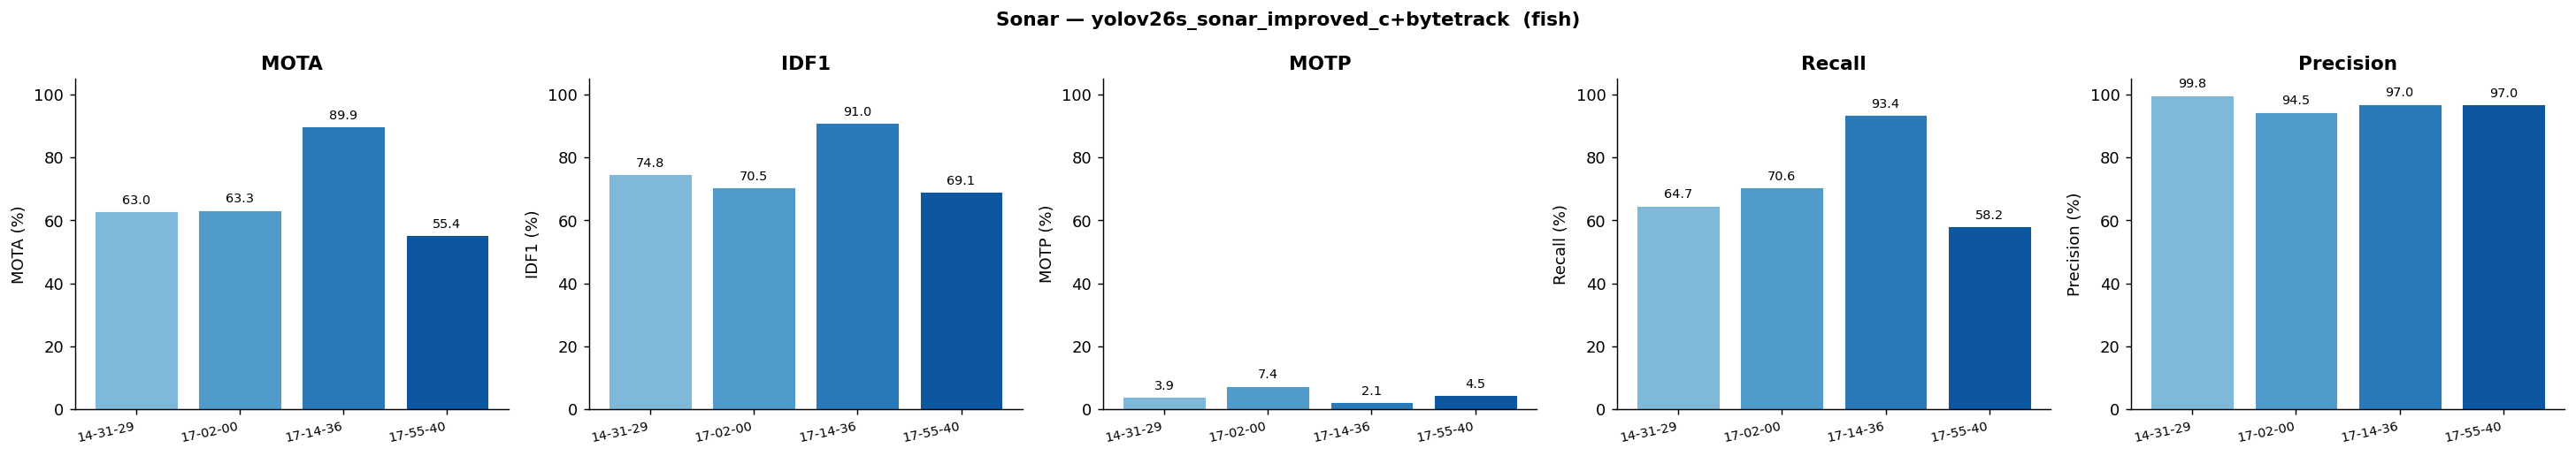

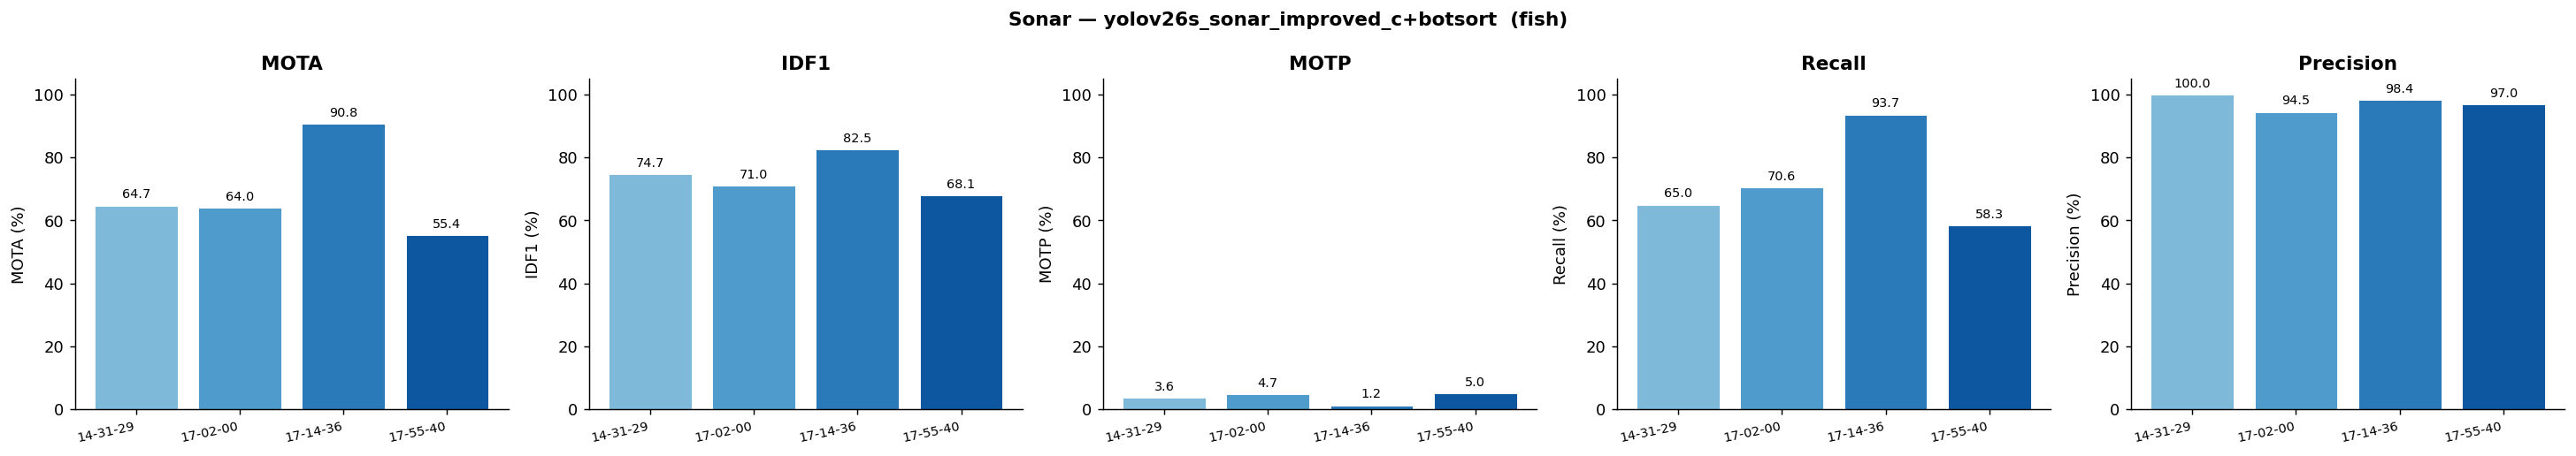

In [8]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_metrics_bar(results_fish_by_tracker[tracker],
                           metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                           title=f"Sonar — {run_tag}  (fish)")
    plt.savefig(f"outputs/sonar_{run_tag}_fish_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6  Metrics bar charts — net

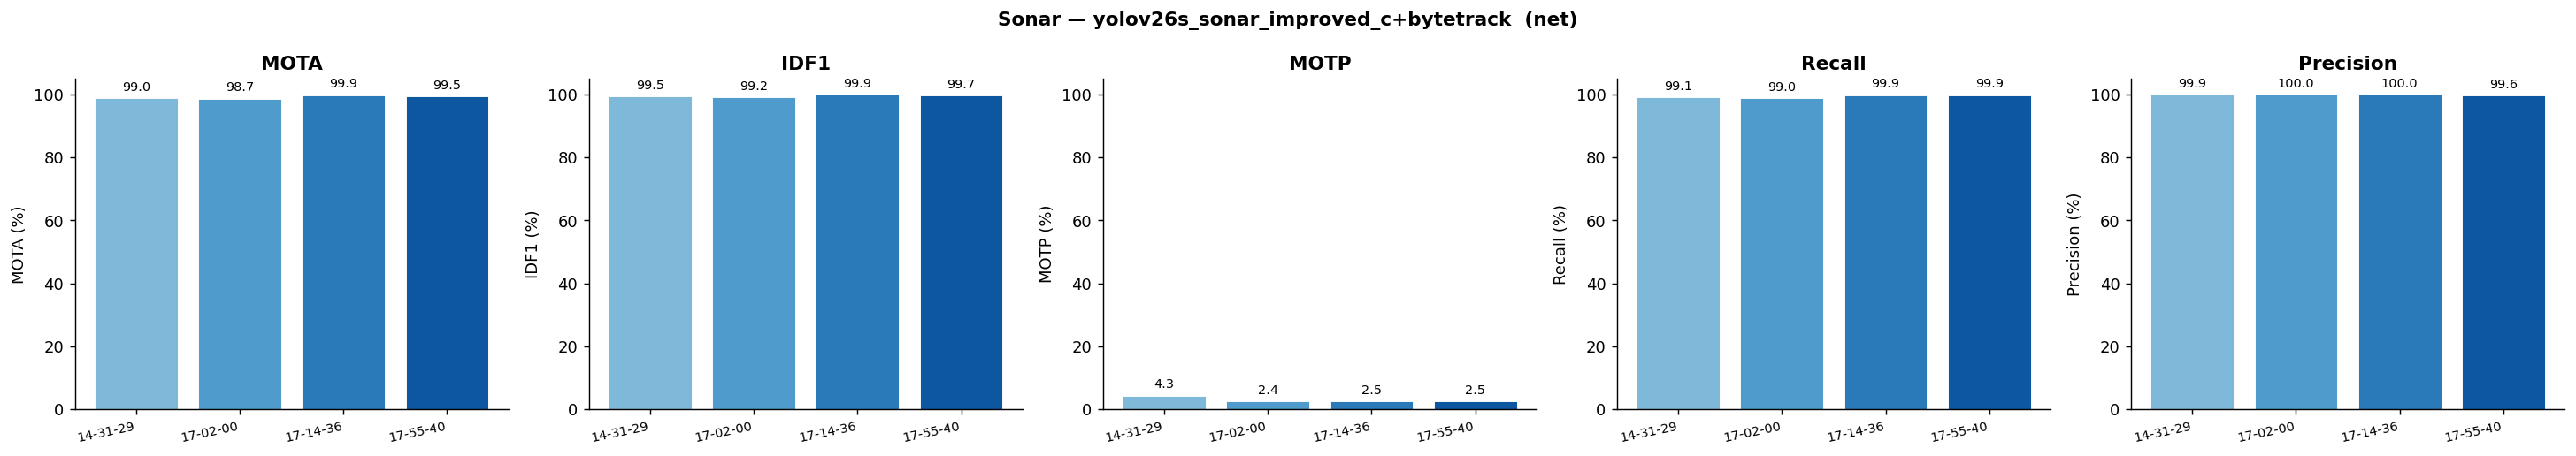

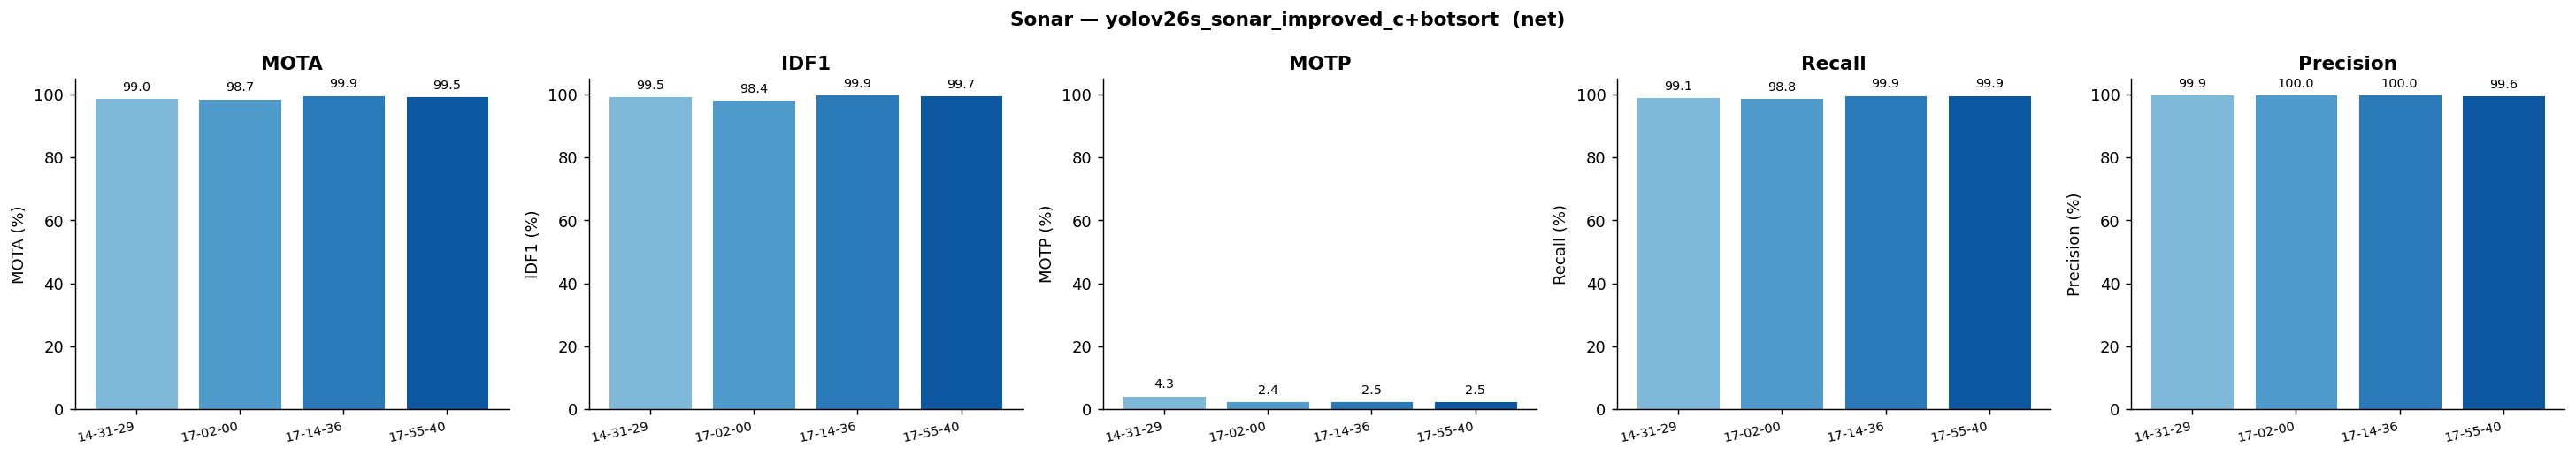

In [9]:
for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    res_net  = results_net_by_tracker[tracker]
    if res_net:
        fig = plot_metrics_bar(res_net,
                               metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                               title=f"Sonar — {run_tag}  (net)")
        # plt.savefig(f"outputs/sonar_{run_tag}_net_metrics_bar.png", dpi=150, bbox_inches="tight")
        plt.show()
    else:
        print(f"{tracker}: No net GT found in any sequence.")


## 7  Error breakdown — fish

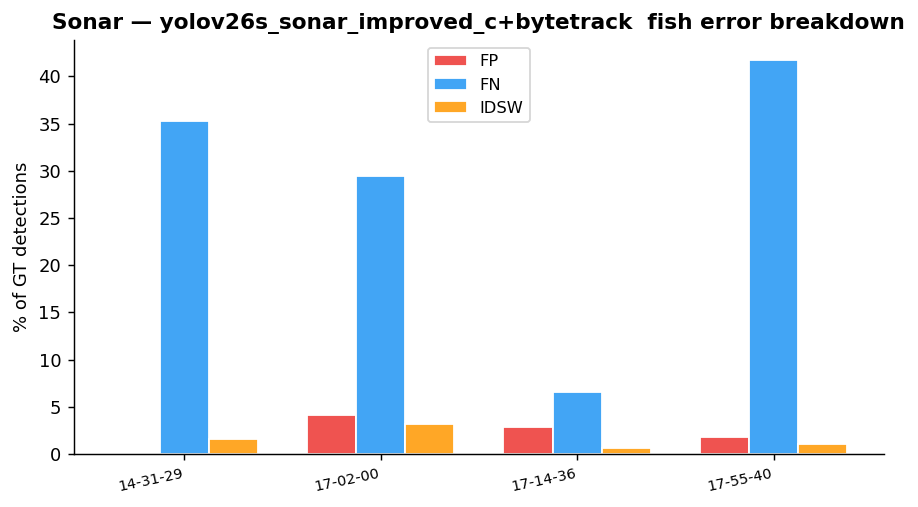

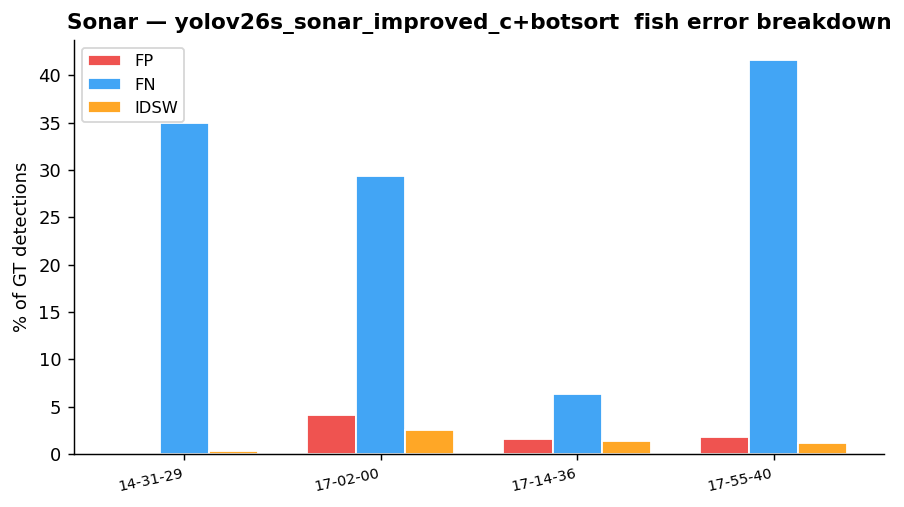

In [10]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_error_breakdown(results_fish_by_tracker[tracker],
                               title=f"Sonar — {run_tag}  fish error breakdown")
    # plt.savefig(f"outputs/sonar_{run_tag}_fish_error_breakdown.png", dpi=150, bbox_inches="tight")
    plt.show()


## 8  GT vs predicted track counts — fish

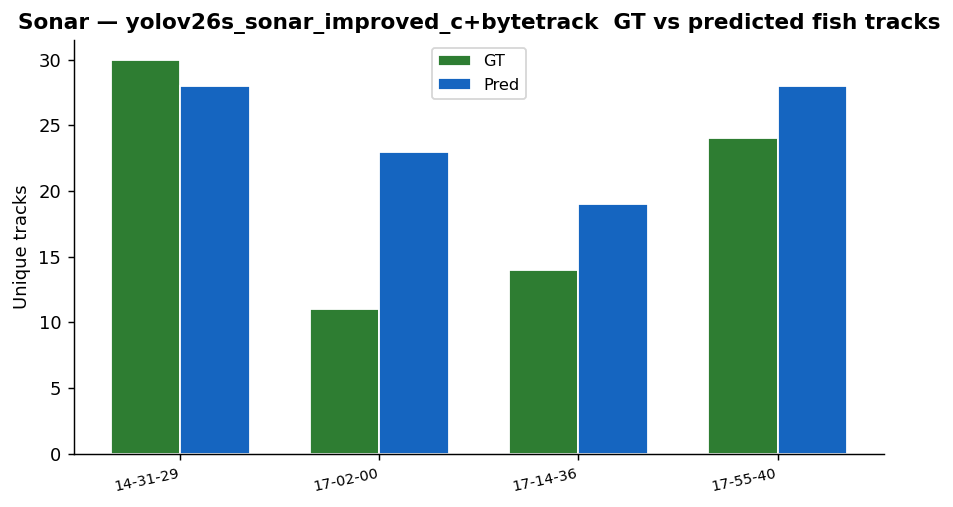

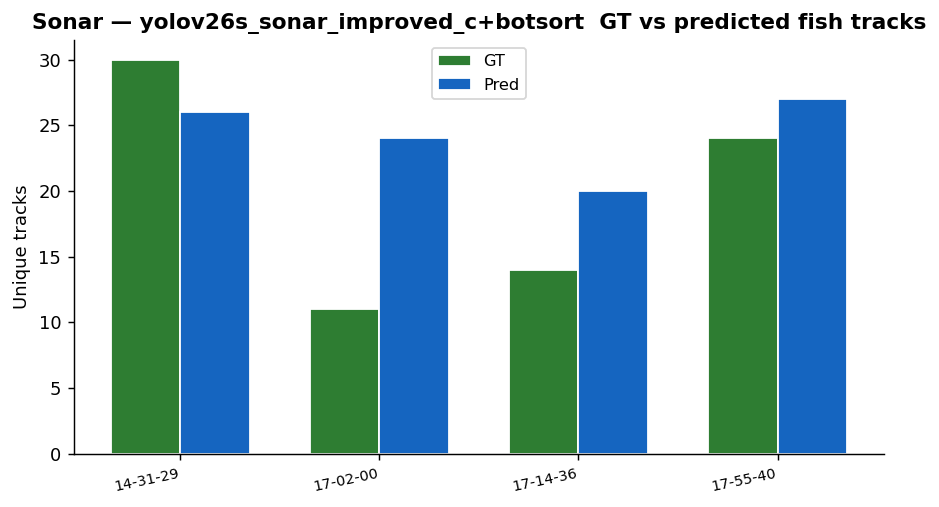

In [11]:
for tracker in TRACKERS:
    run_tag    = f"{MODEL_NAME}+{tracker}"
    gt_fish    = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish  = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                  if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                  for s in SEQUENCES}
    fig = plot_track_comparison(gt_fish, pred_fish)
    plt.title(f"Sonar — {run_tag}  GT vs predicted fish tracks", fontweight="bold")
    # plt.savefig(f"outputs/sonar_{run_tag}_track_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


## 9  Detection count per frame — GT vs predicted (fish)

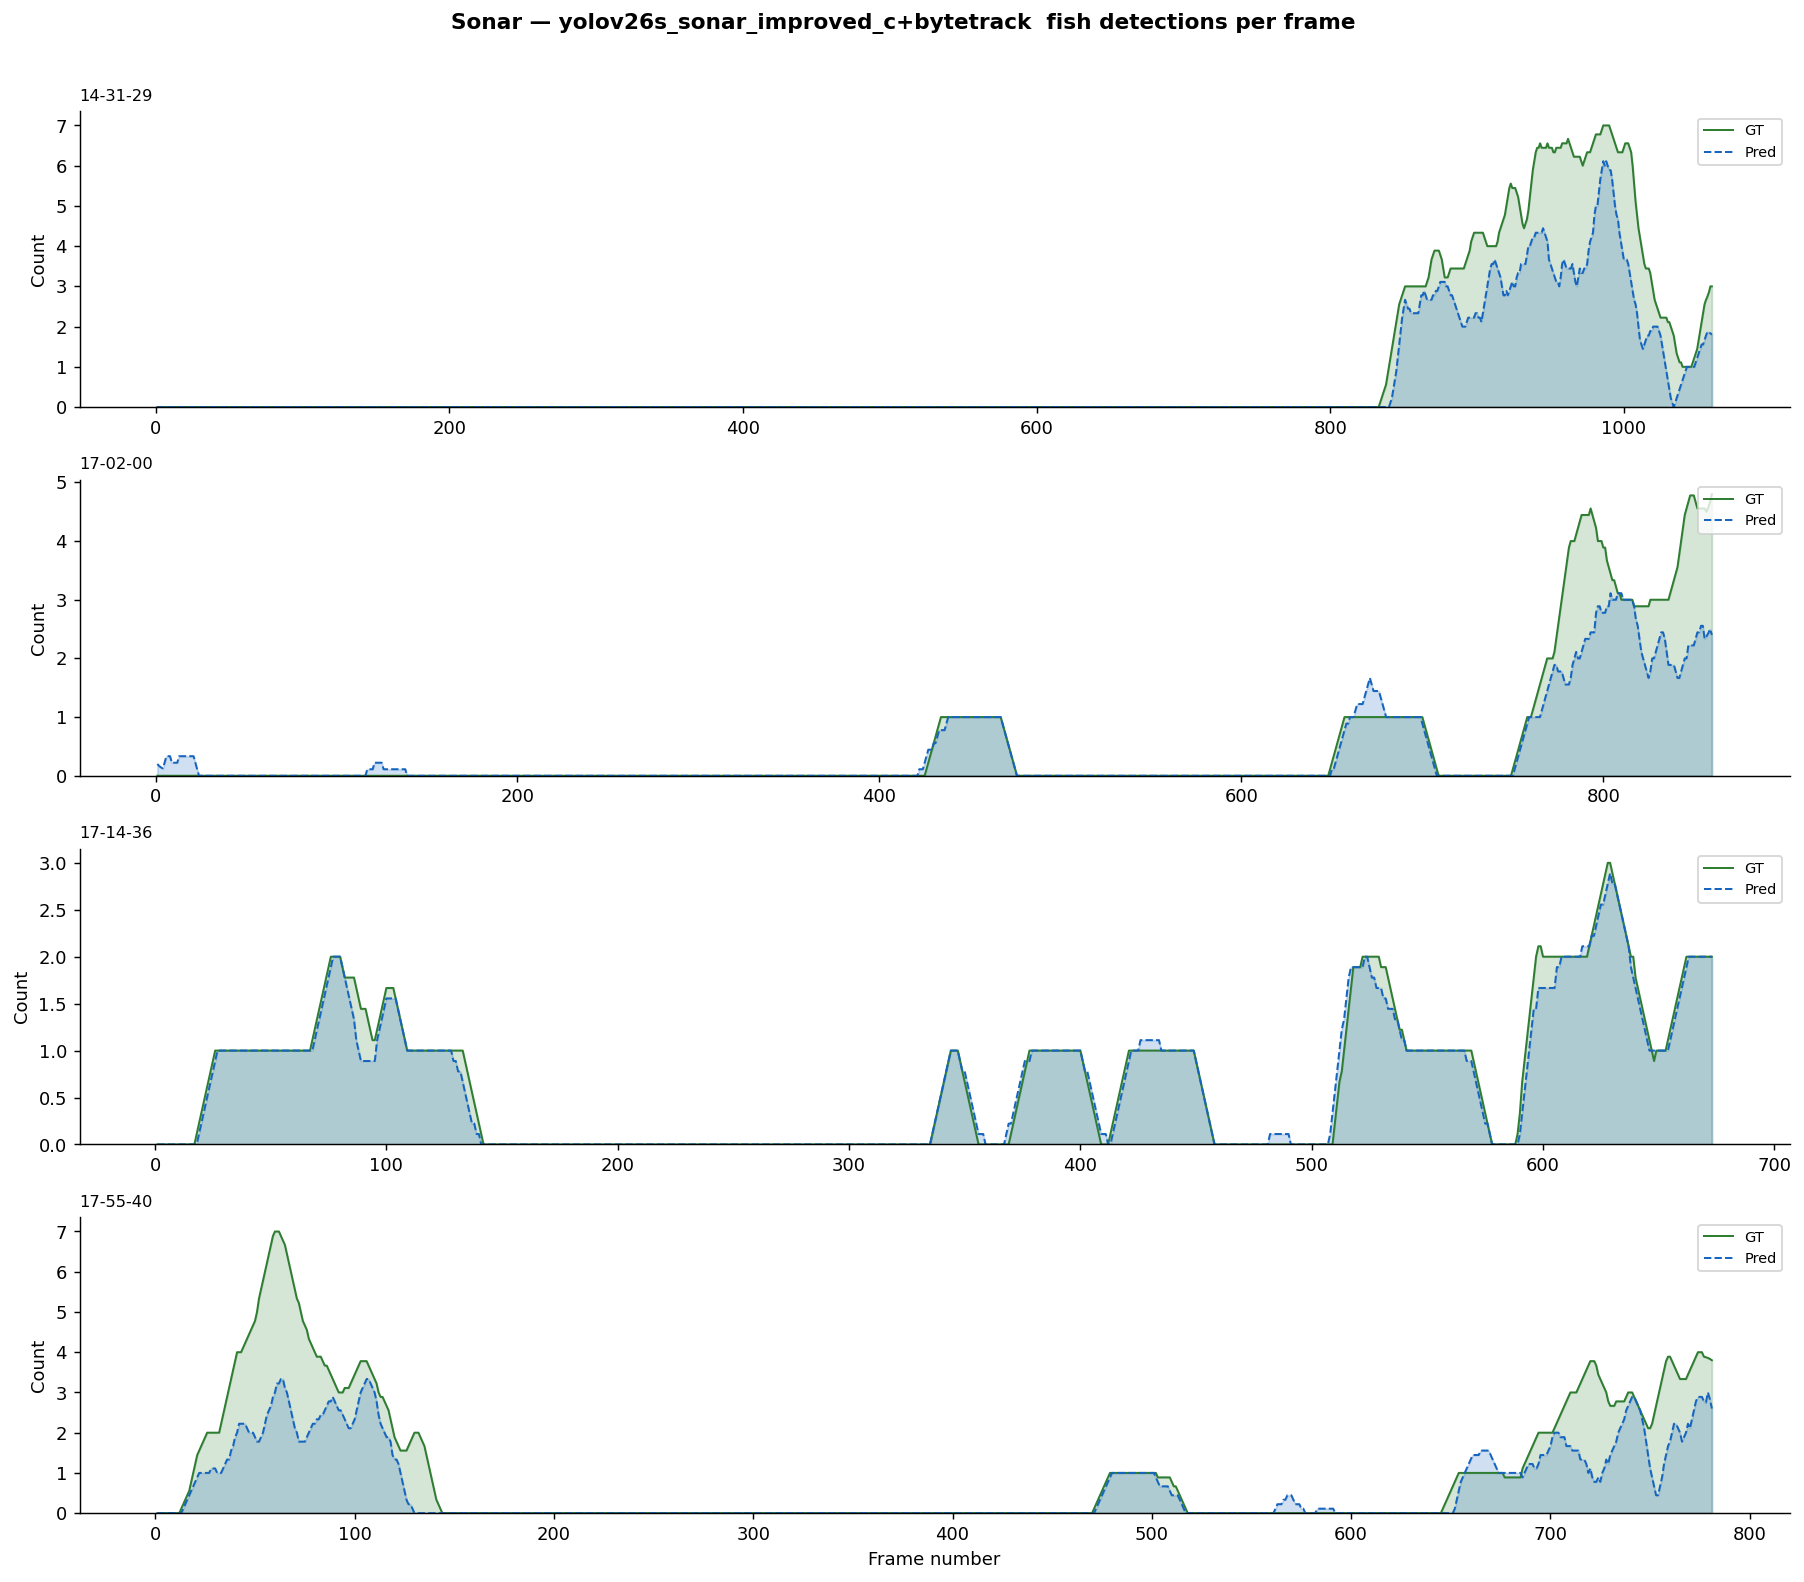

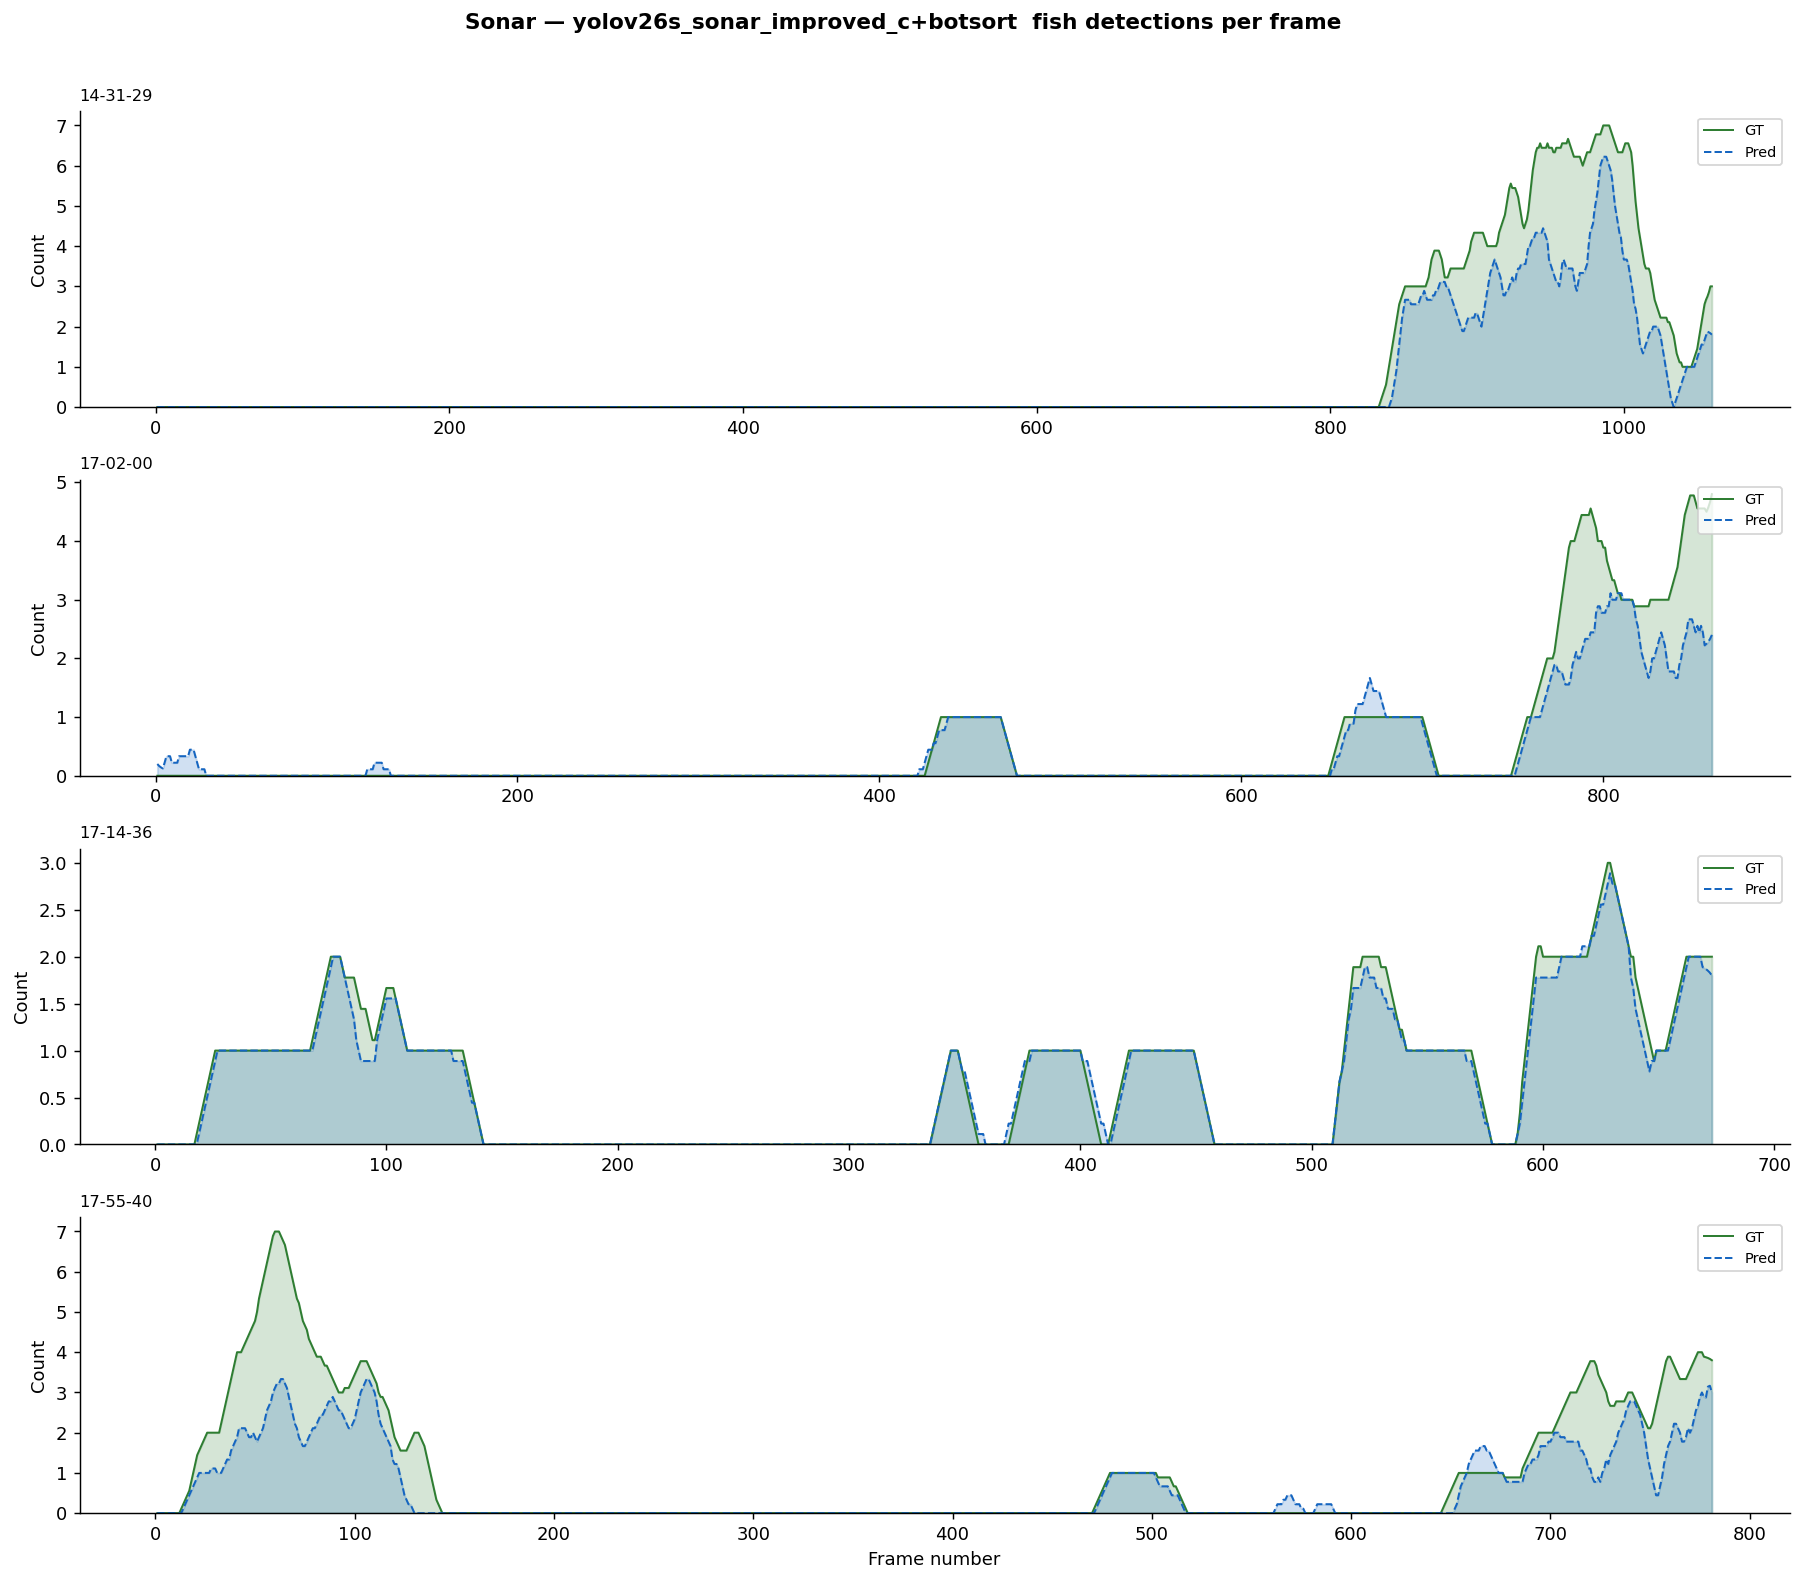

In [12]:
for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    gt_fish   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                 if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                 for s in SEQUENCES}
    fig = plot_det_timeline(gt_fish, pred_fish, total_frames,
                            title=f"Sonar — {run_tag}  fish detections per frame")
    # plt.savefig(f"outputs/sonar_{run_tag}_det_timeline.png", dpi=150, bbox_inches="tight")
    plt.show()


## 10  Cumulative ID switches — fish

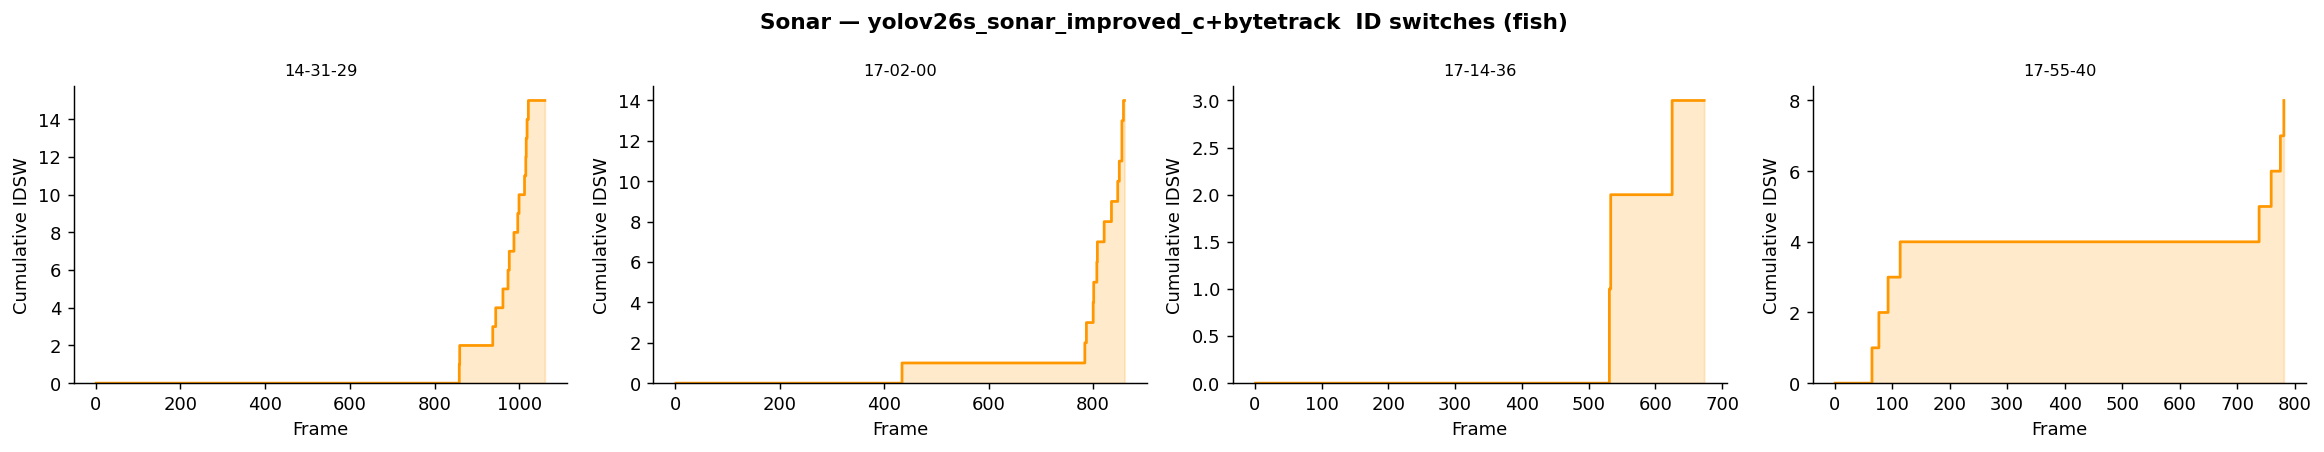

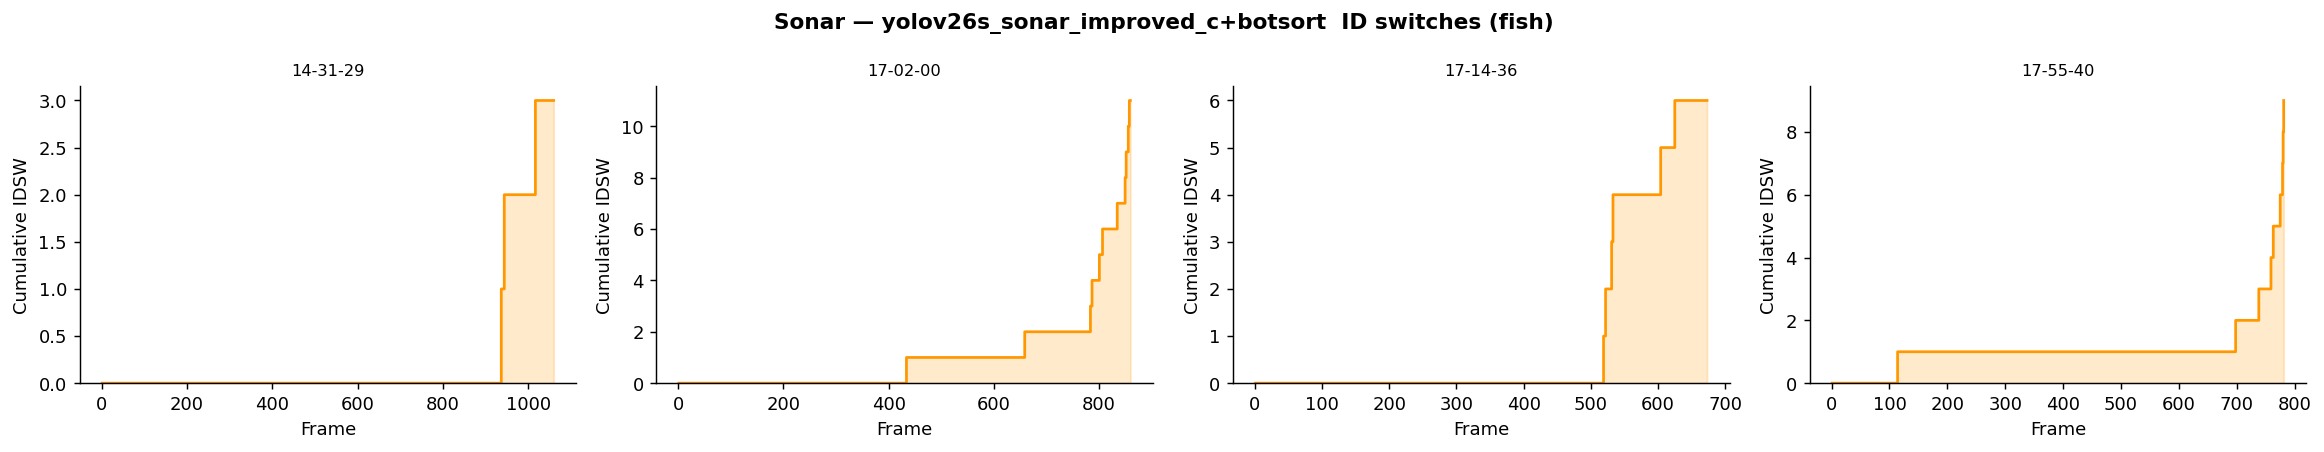

In [13]:
for tracker in TRACKERS:
    run_tag = f"{MODEL_NAME}+{tracker}"
    fig = plot_id_switches(accs_fish_by_tracker[tracker], total_frames,
                           title=f"Sonar — {run_tag}  ID switches (fish)")
    # plt.savefig(f"outputs/sonar_{run_tag}_id_switches.png", dpi=150, bbox_inches="tight")
    plt.show()


## 11  Net range error (sonar physical space)
Compare predicted vs GT net bounding box centre range (metres from sonar).

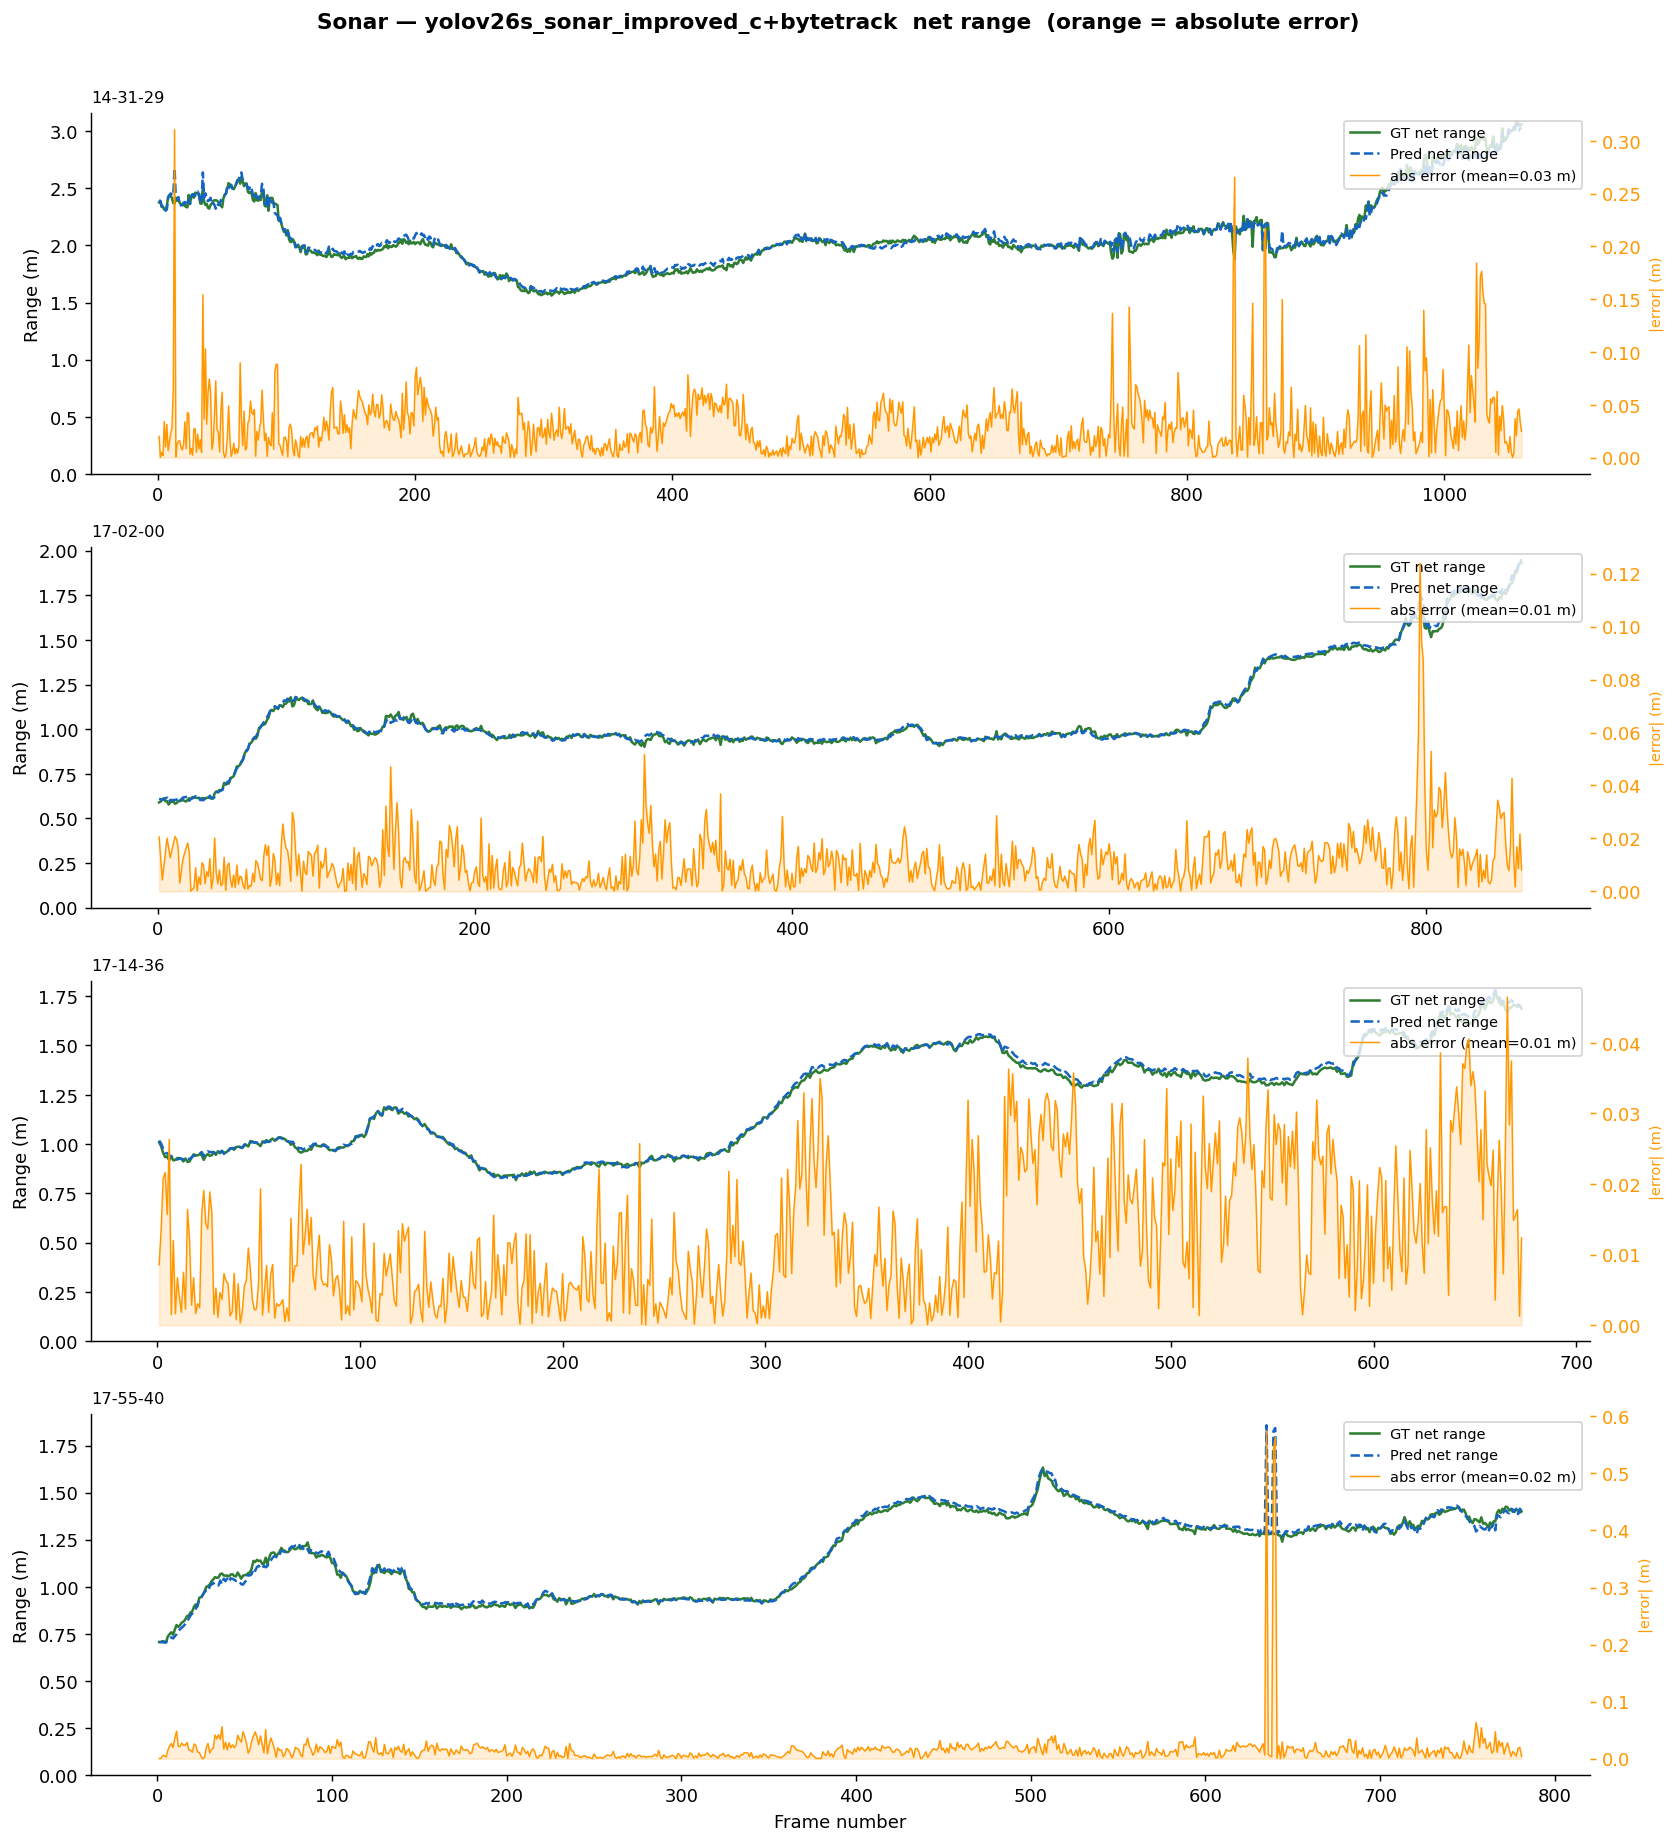

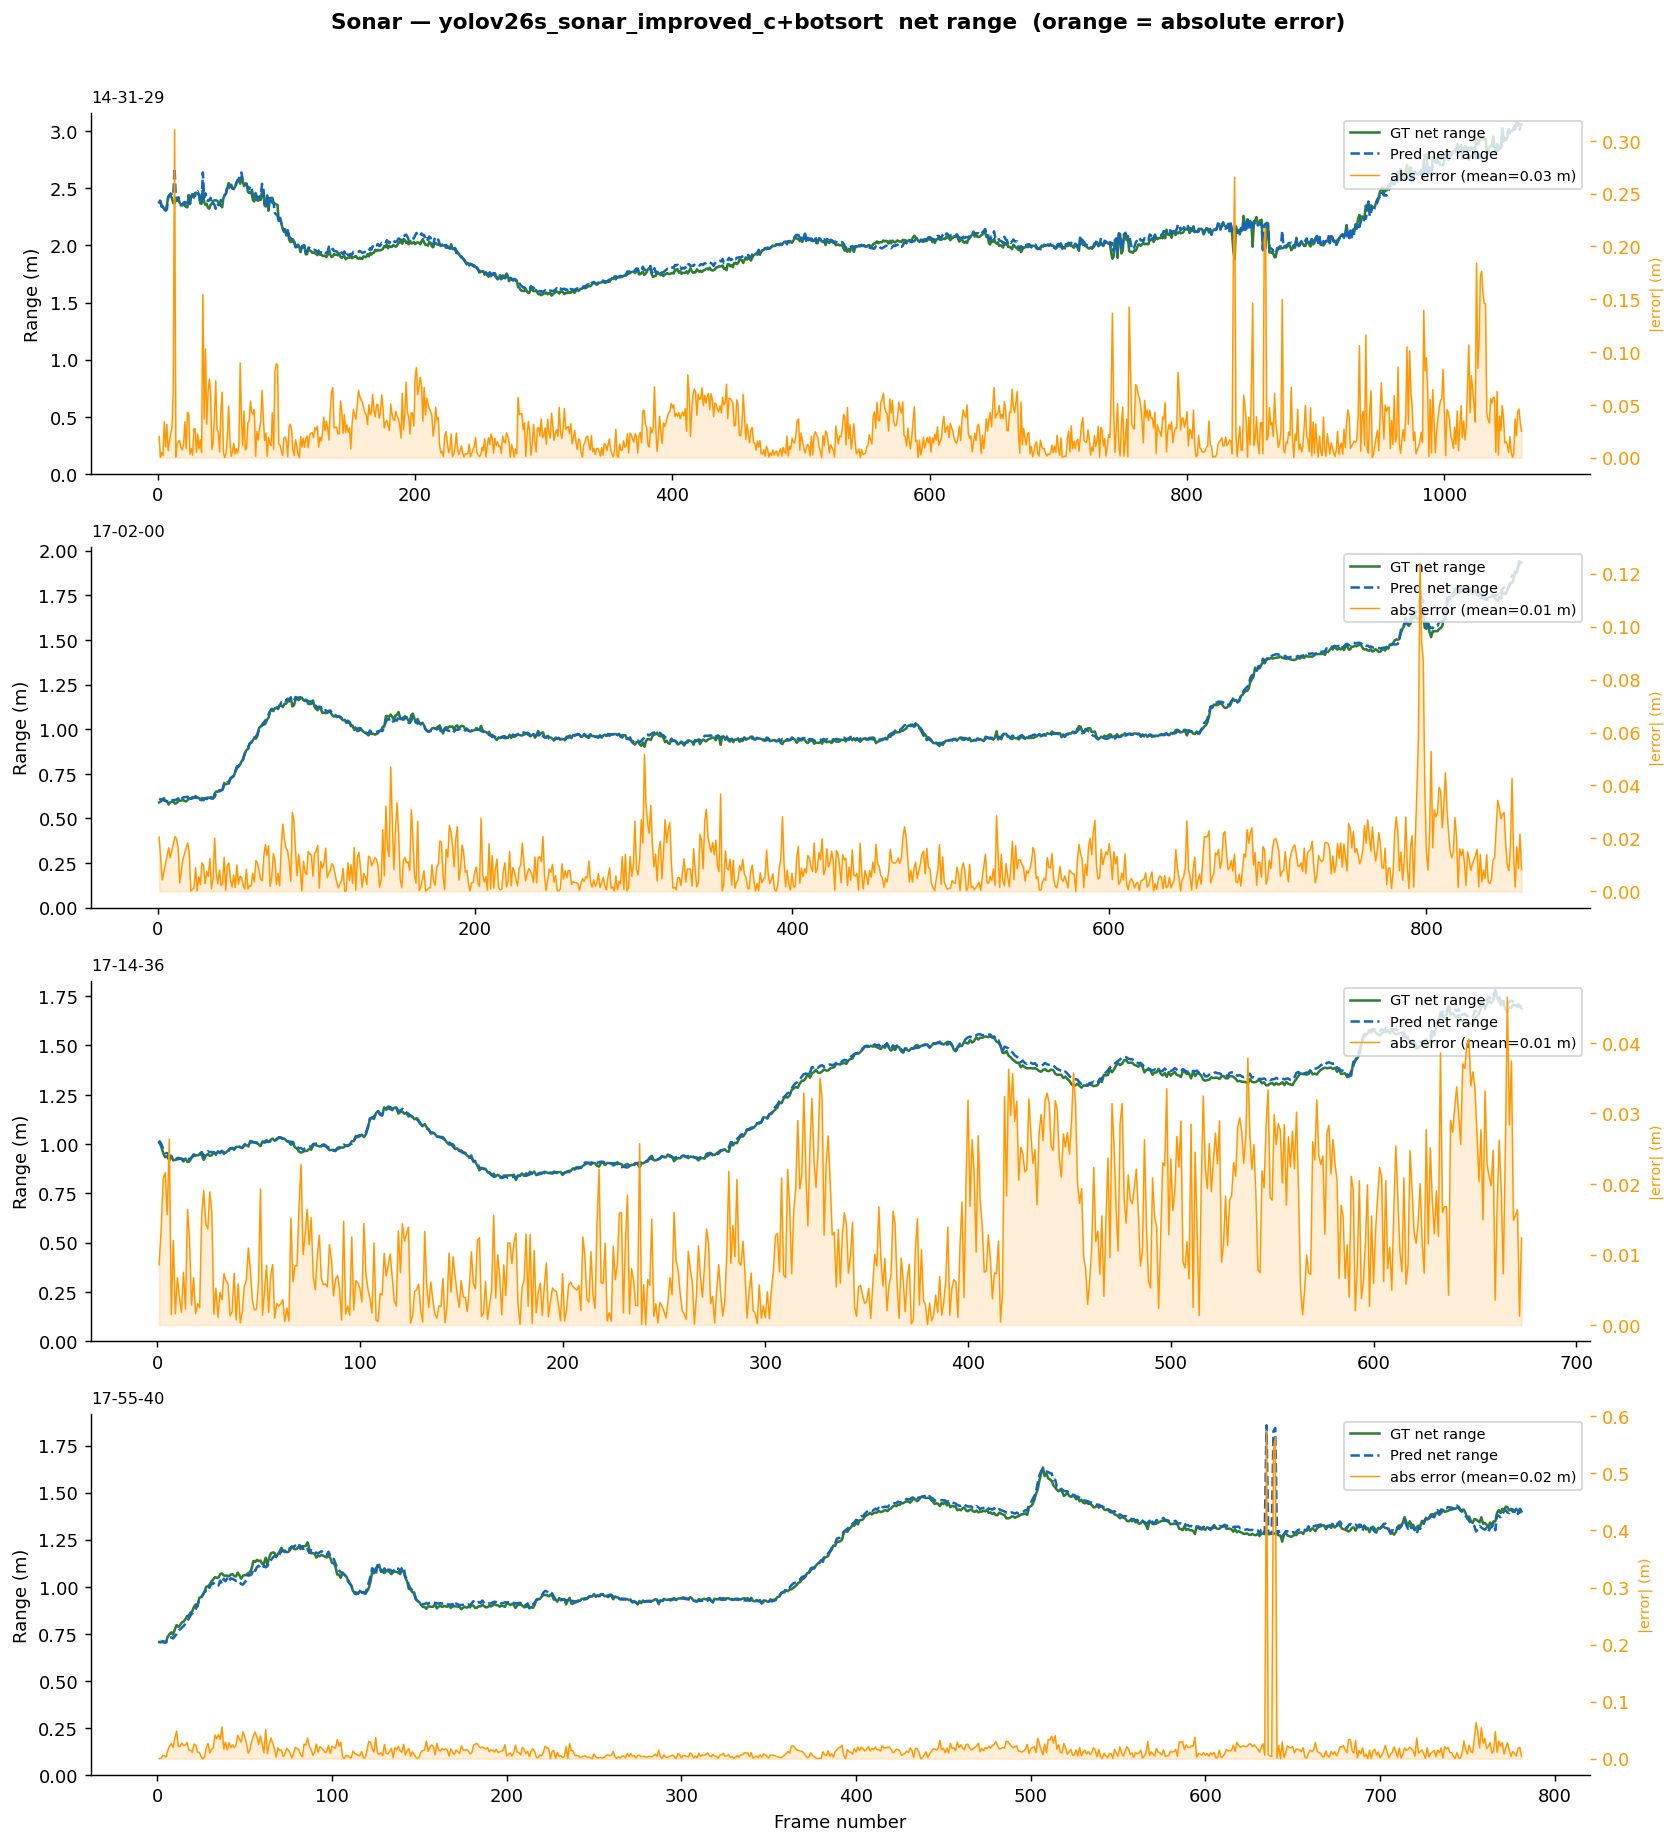

In [14]:
def add_range_m(df):
    cx = df["x"] + df["w"] / 2
    cy = df["y"] + df["h"] / 2
    _, _, rng = sonar_px_to_m(cx, cy)
    df = df.copy()
    df["range_m"] = rng
    return df

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    gt_net   = {s: gt_all[s][gt_all[s]["class_id"] == 2].copy() for s in SEQUENCES}
    pred_net = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 2].copy()
                if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                for s in SEQUENCES}

    fig, axes = plt.subplots(len(SEQUENCES), 1, figsize=(13, 3.5 * len(SEQUENCES)))
    if len(SEQUENCES) == 1:
        axes = [axes]

    for ax, seq in zip(axes, SEQUENCES):
        gn = add_range_m(gt_net.get(seq, pd.DataFrame()))
        pn = add_range_m(pred_net.get(seq, pd.DataFrame()))

        if gn.empty:
            ax.set_title(f"{seq[-8:]} — no net GT", fontsize=9)
            continue

        gt_r = gn.groupby("frame_norm")["range_m"].median()
        ax.plot(gt_r.index, gt_r.values, lw=1.4, color="#2E7D32", label="GT net range")

        if not pn.empty:
            pr_r = pn.groupby("frame_norm")["range_m"].median()
            ax.plot(pr_r.index, pr_r.values, lw=1.4, color="#1565C0",
                    ls="--", label="Pred net range")
            merged = gt_r.rename("gt").to_frame().join(pr_r.rename("pr"), how="inner")
            err = (merged["pr"] - merged["gt"]).abs()
            ax2 = ax.twinx()
            ax2.fill_between(err.index, err.values, alpha=0.15, color="#FF9800")
            ax2.plot(err.index, err.values, lw=0.8, color="#FF9800",
                     label=f"abs error (mean={err.mean():.2f} m)")
            ax2.set_ylabel("|error| (m)", color="#FF9800", fontsize=8)
            ax2.tick_params(axis="y", colors="#FF9800")
            ax2.spines[["top", "bottom", "left"]].set_visible(False)
            h2, l2 = ax2.get_legend_handles_labels()
        else:
            h2, l2 = [], []

        ax.set_ylabel("Range (m)")
        ax.set_title(seq[-8:], fontsize=9, loc="left")
        ax.set_ylim(bottom=0)
        h1, l1 = ax.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Frame number")
    fig.suptitle(f"Sonar — {run_tag}  net range  (orange = absolute error)",
                 fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    # plt.savefig(f"outputs/sonar_{run_tag}_net_range_error.png", dpi=150, bbox_inches="tight")
    plt.show()


## 12  MT / PT / ML breakdown — fish

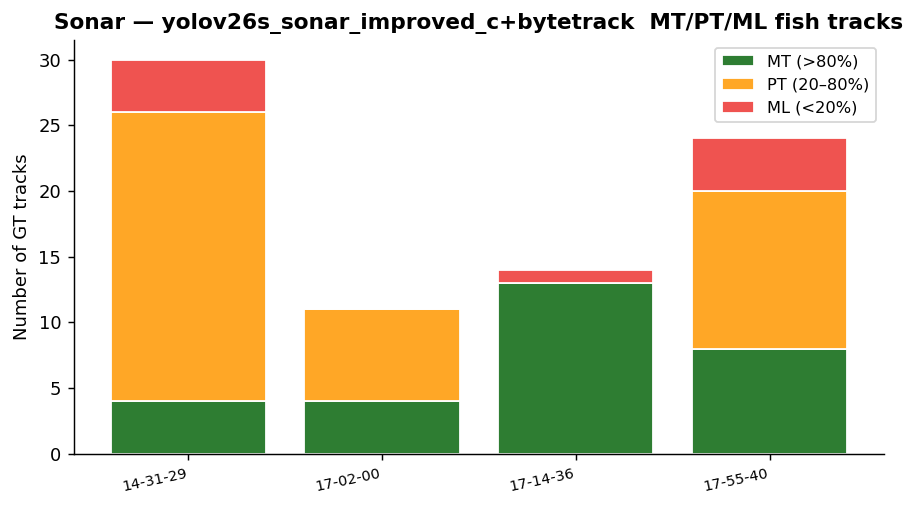

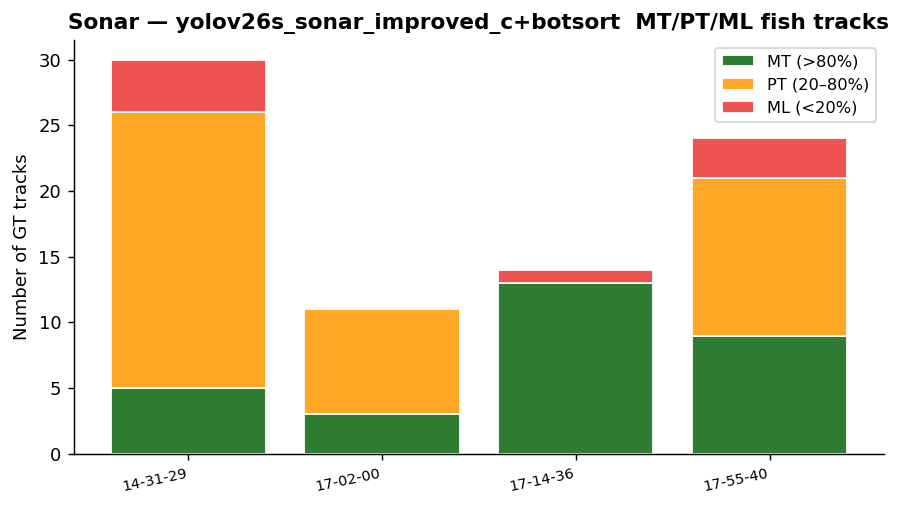

In [15]:
for tracker in TRACKERS:
    run_tag   = f"{MODEL_NAME}+{tracker}"
    res_fish  = results_fish_by_tracker[tracker]
    seq_names = list(res_fish.keys())
    mt_vals   = [int(res_fish[s]["mostly_tracked"].iloc[0])   for s in seq_names]
    pt_vals   = [int(res_fish[s]["partially_tracked"].iloc[0]) for s in seq_names]
    ml_vals   = [int(res_fish[s]["mostly_lost"].iloc[0])       for s in seq_names]

    x = np.arange(len(seq_names))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x, mt_vals, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, pt_vals, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, ml_vals, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.set_title(f"Sonar — {run_tag}  MT/PT/ML fish tracks", fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
#     plt.savefig(f"outputs/sonar_{run_tag}_mt_pt_ml.png", dpi=150, bbox_inches="tight")
    plt.show()


## V2  GT vs inference frame comparison
Green = ground truth boxes, red = predicted boxes.  
Set `COMPARE_CLASS` to 1 (fish) or 2 (net), and `CMP_TRACKER` to select tracker.

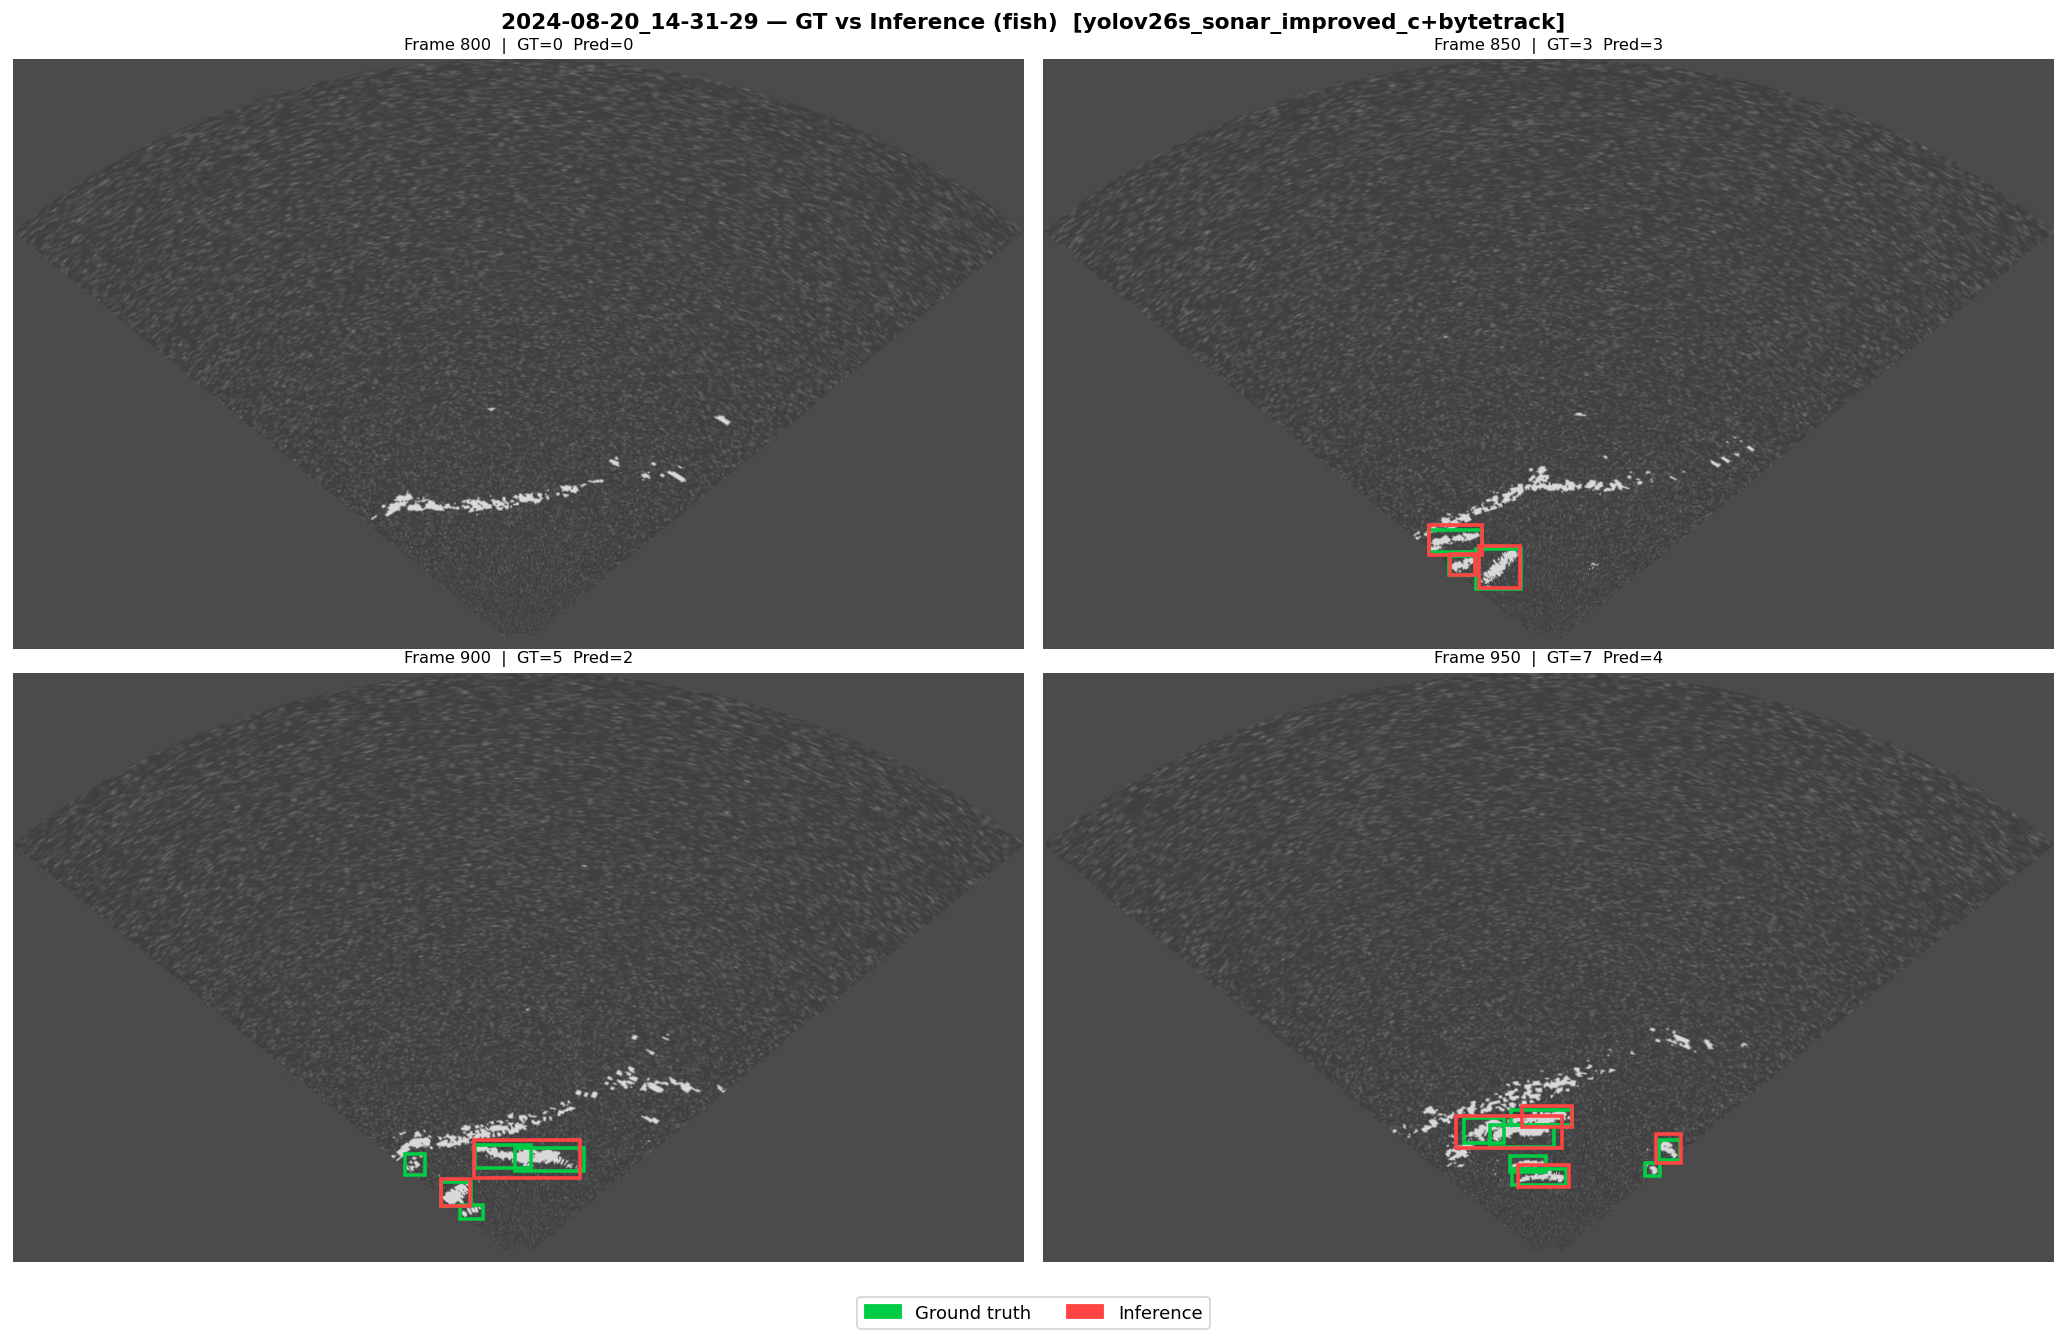

In [16]:
# ── Config ────────────────────────────────────────────────────────────────────
CMP_TRACKER    = TRACKERS[0]  # "bytetrack" or "botsort"
COMPARE_SEQ    = SEQUENCES[0]
COMPARE_FRAMES = [800, 850, 900, 950]
COMPARE_CLASS  = 1                      # 1 = fish, 2 = net
NCOLS          = 2

GT_COLOR   = "#00CC44"
PRED_COLOR = "#FF4444"

idir_c      = img_dir_for(SONAR_ROOT / COMPARE_SEQ, "sonar")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_all[COMPARE_SEQ][gt_all[COMPARE_SEQ]["class_id"] == COMPARE_CLASS]
pred_src    = pred_by_tracker[CMP_TRACKER][COMPARE_SEQ]
pred_c      = pred_src[pred_src["class_id"] == COMPARE_CLASS] if not pred_src.empty else pred_src

valid_frames = [fn for fn in COMPARE_FRAMES if fn in fn_to_img_c]
nrows = (len(valid_frames) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 8, nrows * 5))
axes = np.array(axes).flatten()

for i, fn in enumerate(valid_frames):
    ax = axes[i]
    img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img_c[fn])), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    for _, row in gt_c[gt_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=GT_COLOR, facecolor="none"))
    for _, row in pred_c[pred_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=PRED_COLOR, facecolor="none"))
    n_gt   = (gt_c["frame_norm"]   == fn).sum()
    n_pred = (pred_c["frame_norm"] == fn).sum()
    ax.set_title(f"Frame {fn}  |  GT={n_gt}  Pred={n_pred}", fontsize=9)
    ax.axis("off")

for j in range(len(valid_frames), len(axes)):
    axes[j].set_visible(False)

class_label = {1: "fish", 2: "net"}.get(COMPARE_CLASS, str(COMPARE_CLASS))
fig.legend(
    handles=[
        mpatches.Patch(color=GT_COLOR,   label="Ground truth"),
        mpatches.Patch(color=PRED_COLOR, label="Inference"),
    ],
    loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04),
)
run_tag_cmp = f"{MODEL_NAME}+{CMP_TRACKER}"
fig.suptitle(f"{COMPARE_SEQ} — GT vs Inference ({class_label})  [{run_tag_cmp}]",
             fontsize=12, fontweight="bold")
plt.tight_layout()
# plt.savefig(f"outputs/sonar_{run_tag_cmp}_gt_vs_pred_{class_label}.png", dpi=150, bbox_inches="tight")
plt.show()


## Combined — all sequences
Aggregates all selected sequences per tracker.  
Shows combined tables for fish, net, and all-class (fish + net).  
Frame and track IDs are offset per sequence to avoid collisions.


  TRACKER: BYTETRACK
Fish combined: HOTA=58.4%  MOTA=65.5%  IDF1=75.7%  IDSW=40

Run: yolov26s_sonar_improved_c+bytetrack  (fish)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,55.7%,42.8%,86.1%,63.0%,74.8%,3.9%,64.7%,99.8%,1,334,15,4,4,30
1,17-02-00,55.9%,47.8%,73.6%,63.3%,70.5%,7.4%,70.6%,94.5%,18,130,14,4,0,11
2,17-14-36,74.1%,72.4%,87.2%,89.9%,91.0%,2.1%,93.4%,97.0%,13,30,3,13,1,14
3,17-55-40,52.4%,37.5%,81.5%,55.4%,69.1%,4.5%,58.2%,97.0%,14,326,8,8,4,24
4,COMBINED,58.4%,47.0%,83.6%,65.5%,75.7%,4.2%,68.8%,97.5%,46,820,40,29,9,79


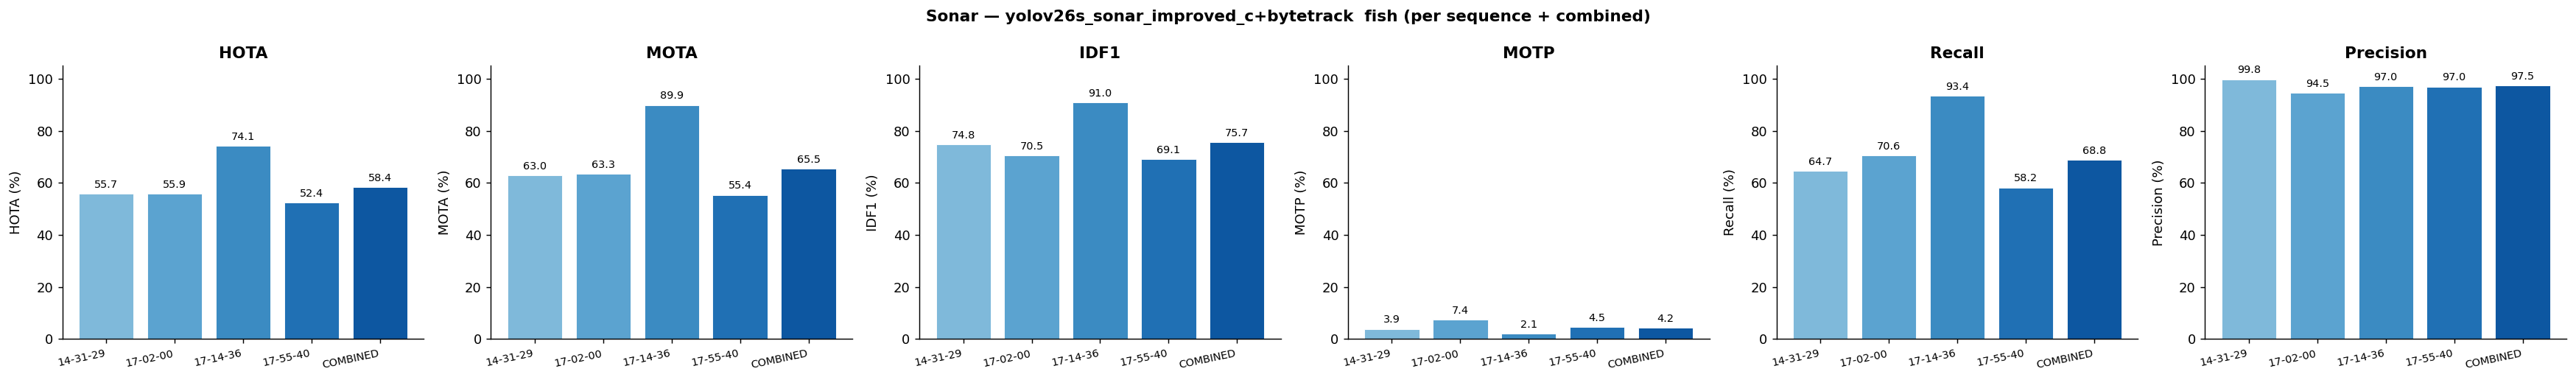

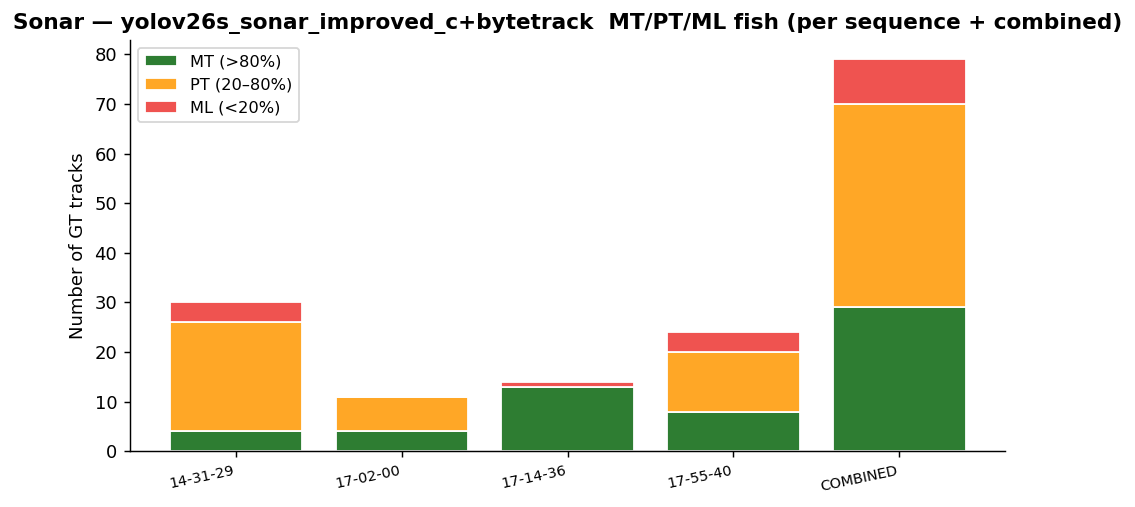

Net combined: HOTA=71.5%  MOTA=99.2%  IDF1=99.6%  IDSW=2

Run: yolov26s_sonar_improved_c+bytetrack  (net)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,69.4%,61.7%,94.4%,98.7%,99.2%,2.4%,99.0%,100.0%,0,9,2,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1
4,COMBINED,71.5%,62.8%,99.9%,99.2%,99.6%,3.0%,99.4%,99.9%,4,21,2,4,0,4


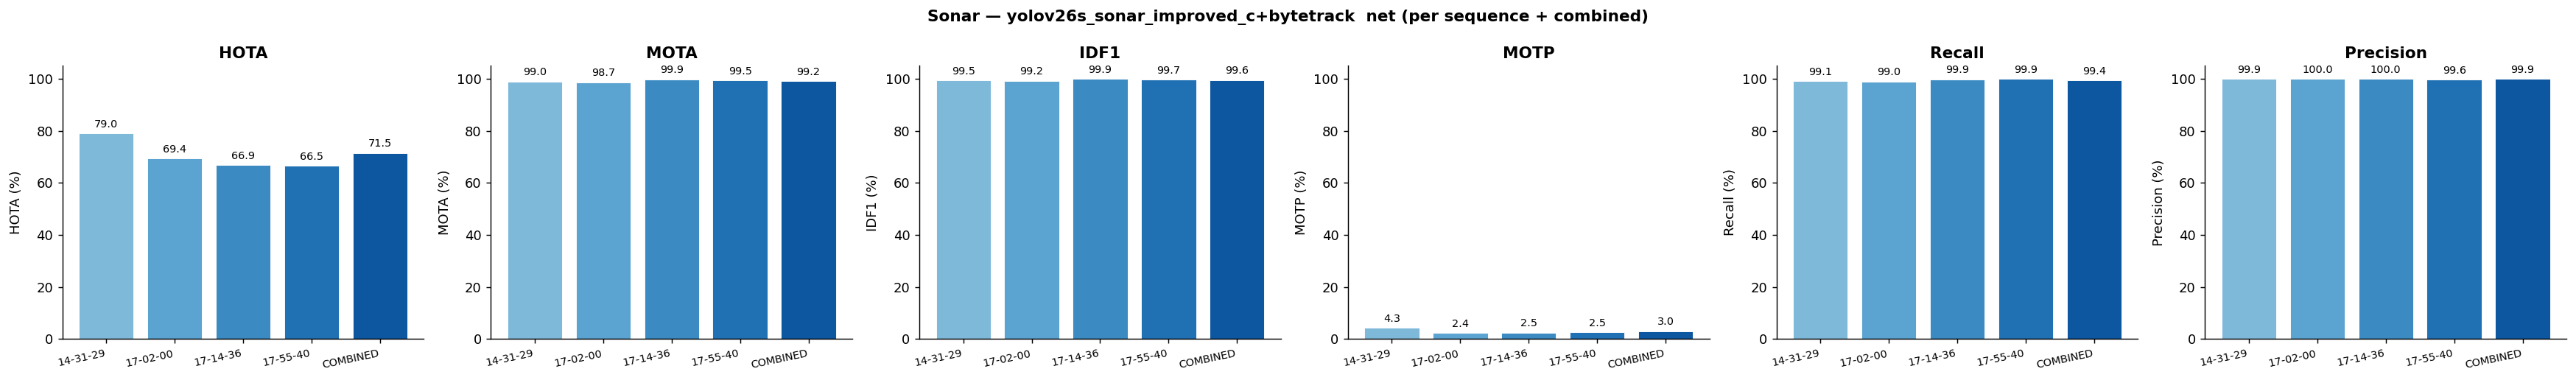

All-class combined: HOTA=66.3%  MOTA=84.6%  IDF1=90.1%  IDSW=42

Run: yolov26s_sonar_improved_c+bytetrack  (fish + net)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,69.0%,58.0%,95.2%,82.0%,89.0%,4.1%,82.9%,99.9%,2,344,15,5,4,31
1,17-02-00,65.6%,57.0%,89.3%,87.5%,90.8%,3.7%,89.7%,98.9%,13,134,16,5,0,12
2,17-14-36,70.0%,62.7%,93.6%,95.8%,96.3%,2.3%,97.3%,98.8%,13,31,3,14,1,15
3,17-55-40,60.1%,47.4%,89.1%,77.5%,86.1%,3.3%,79.1%,98.6%,17,327,8,9,4,25
4,COMBINED,66.3%,55.7%,93.2%,84.6%,90.1%,3.4%,86.1%,99.1%,45,836,42,33,9,83


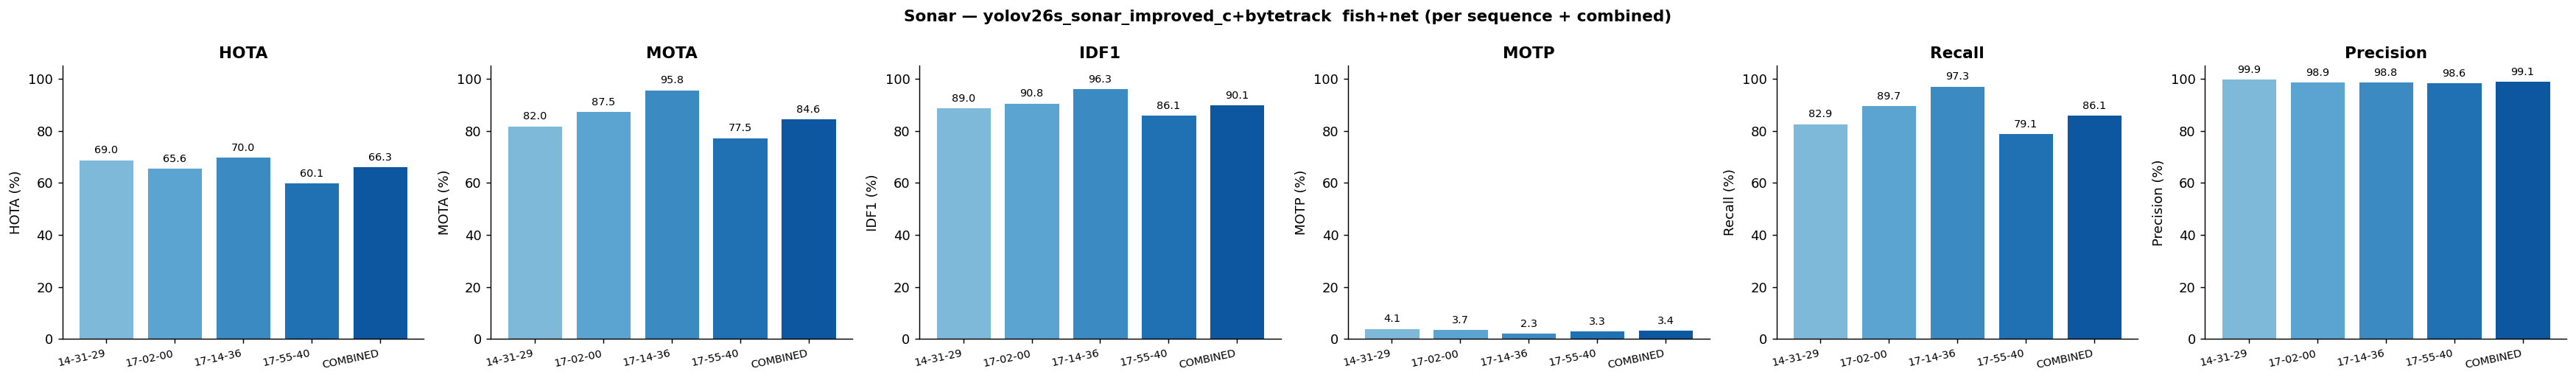


  TRACKER: BOTSORT
Fish combined: HOTA=58.5%  MOTA=66.4%  IDF1=73.8%  IDSW=29

Run: yolov26s_sonar_improved_c+botsort  (fish)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,57.6%,43.4%,90.3%,64.7%,74.7%,3.6%,65.0%,100.0%,0,331,3,5,4,30
1,17-02-00,57.2%,47.4%,79.3%,64.0%,71.0%,4.7%,70.6%,94.5%,18,130,11,3,0,11
2,17-14-36,71.9%,73.5%,81.5%,90.8%,82.5%,1.2%,93.7%,98.4%,7,29,6,13,1,14
3,17-55-40,51.4%,37.4%,79.1%,55.4%,68.1%,5.0%,58.3%,97.0%,14,325,9,9,3,24
4,COMBINED,58.5%,47.2%,83.9%,66.4%,73.8%,3.6%,69.0%,97.9%,39,815,29,30,8,79


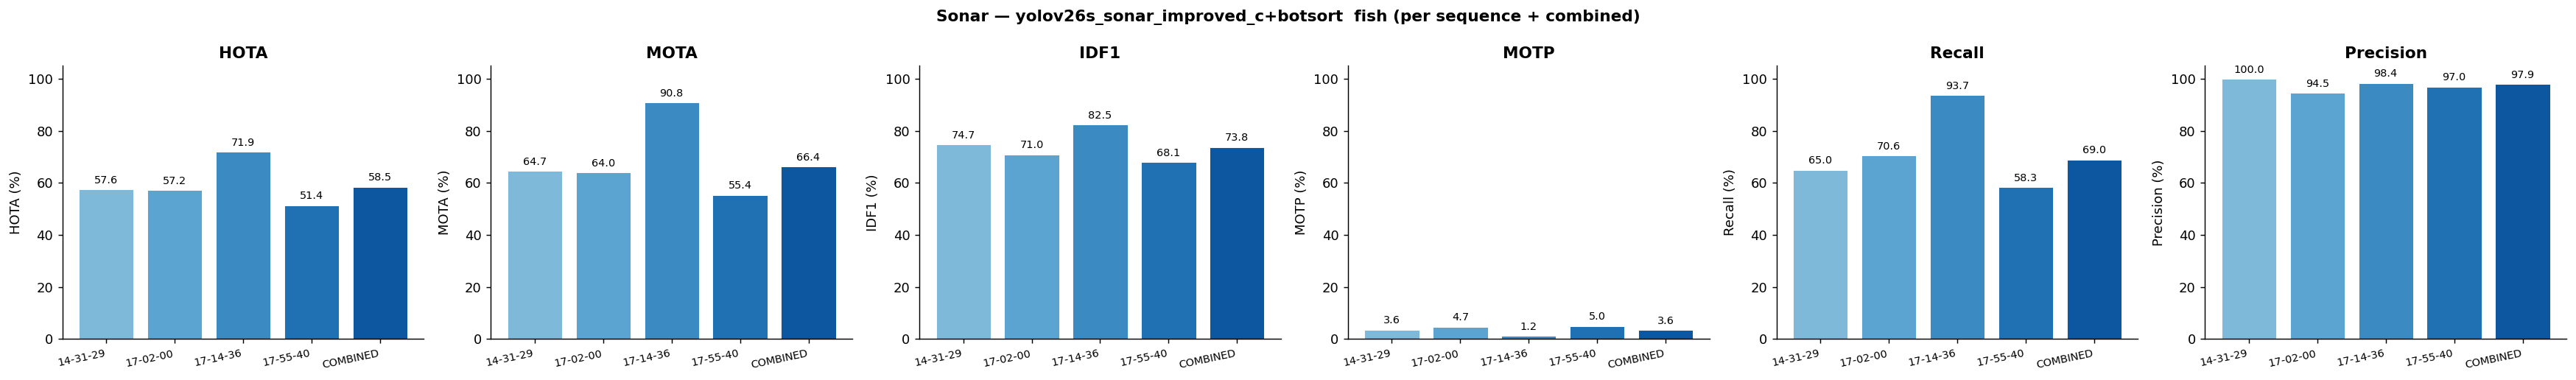

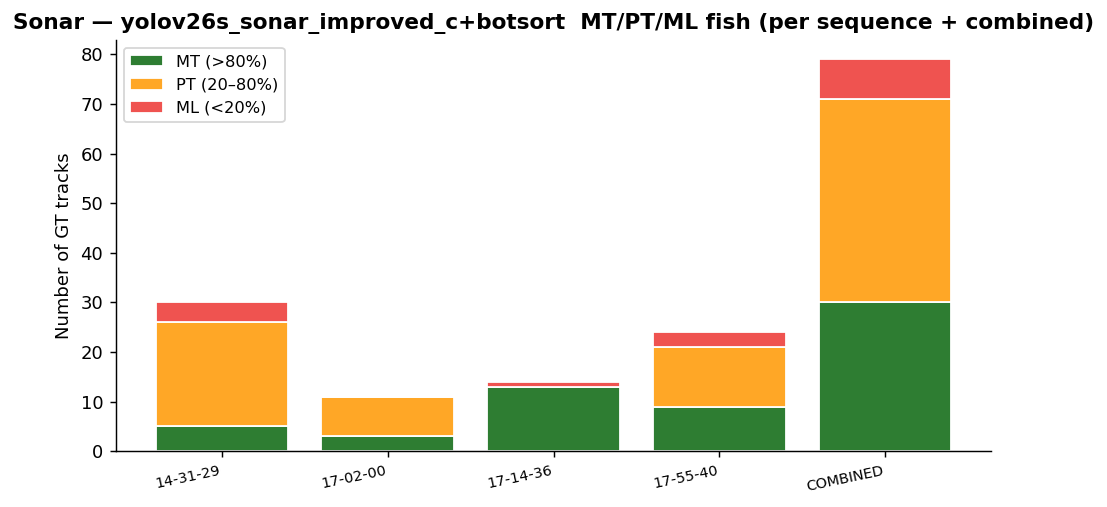

Net combined: HOTA=71.4%  MOTA=99.2%  IDF1=99.3%  IDSW=1

Run: yolov26s_sonar_improved_c+botsort  (net)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,79.0%,71.8%,100.0%,99.0%,99.5%,4.3%,99.1%,99.9%,1,10,0,1,0,1
1,17-02-00,68.9%,61.7%,93.5%,98.7%,98.4%,2.4%,98.8%,100.0%,0,10,1,1,0,1
2,17-14-36,66.9%,58.7%,94.7%,99.9%,99.9%,2.5%,99.9%,100.0%,0,1,0,1,0,1
3,17-55-40,66.5%,58.4%,94.7%,99.5%,99.7%,2.5%,99.9%,99.6%,3,1,0,1,0,1
4,COMBINED,71.4%,62.8%,99.7%,99.2%,99.3%,3.0%,99.3%,99.9%,4,22,1,4,0,4


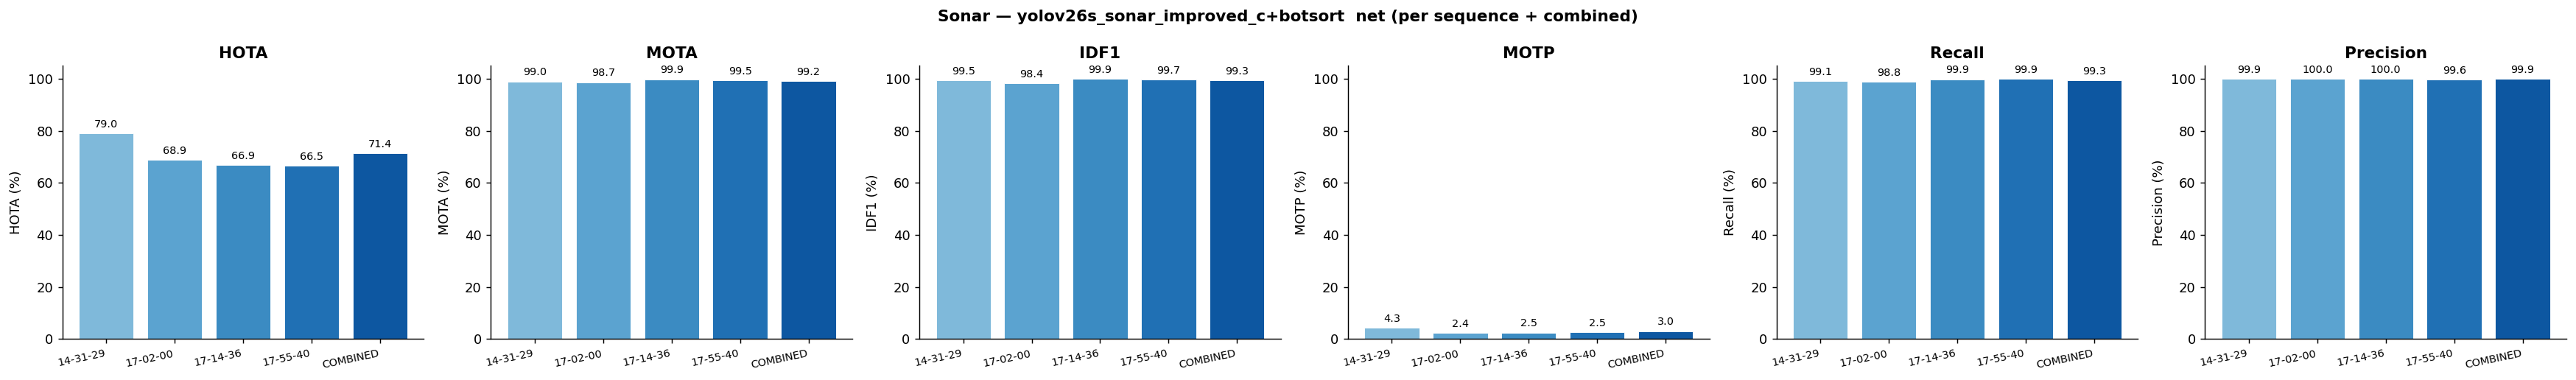

All-class combined: HOTA=66.1%  MOTA=85.0%  IDF1=89.1%  IDSW=30

Run: yolov26s_sonar_improved_c+botsort  (fish + net)


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,69.7%,58.3%,96.6%,82.8%,88.9%,4.0%,83.0%,99.9%,1,341,3,6,4,31
1,17-02-00,65.3%,56.8%,90.4%,87.7%,89.8%,3.0%,89.6%,98.9%,13,135,12,4,0,12
2,17-14-36,69.1%,63.0%,90.7%,96.2%,93.0%,2.0%,97.3%,99.4%,7,30,6,14,1,15
3,17-55-40,59.7%,47.4%,88.2%,77.5%,85.7%,3.4%,79.1%,98.6%,17,326,9,10,3,25
4,COMBINED,66.1%,55.8%,93.0%,85.0%,89.1%,3.2%,86.1%,99.3%,38,832,30,34,8,83


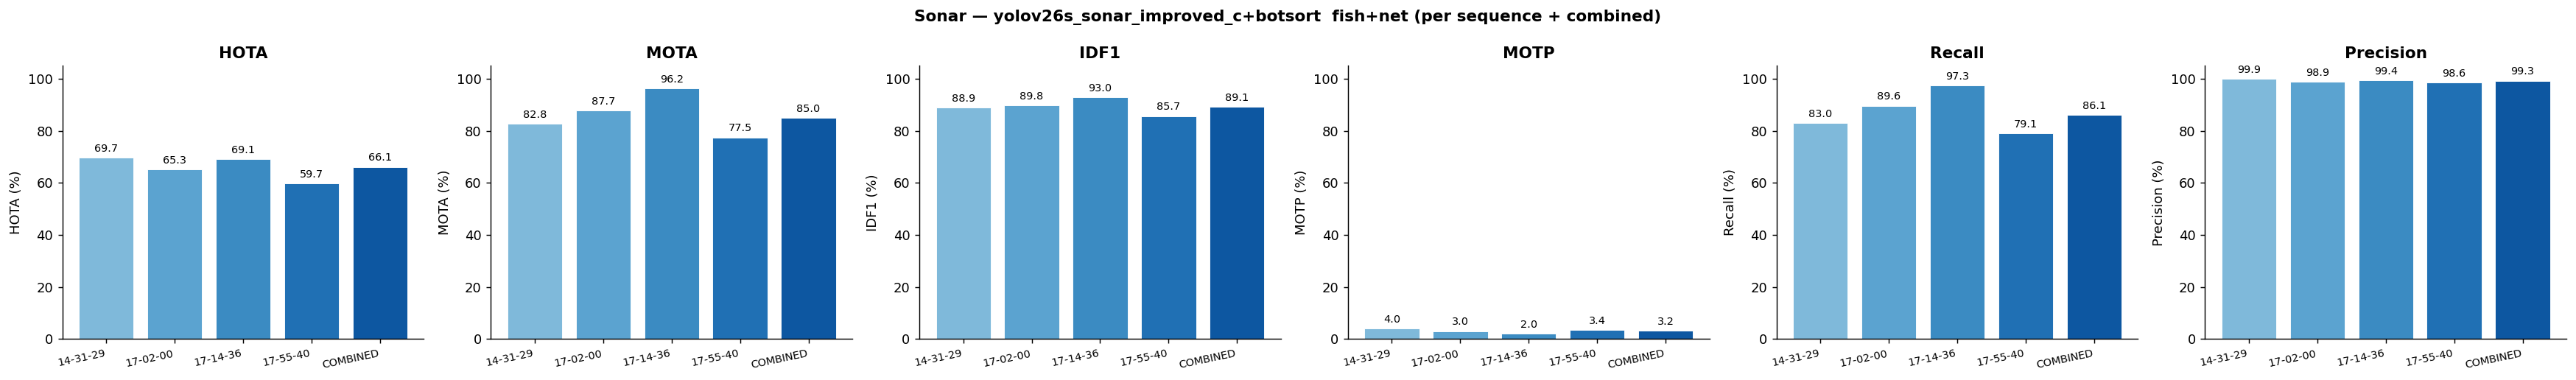

In [17]:
_OFF = 10_000

def _stack(dfs_dict):
    frames = []
    for i, (seq, df) in enumerate(dfs_dict.items()):
        if df.empty:
            continue
        frames.append(df.assign(frame_norm=df["frame_norm"] + i * _OFF,
                                track_id  =df["track_id"]   + i * _OFF))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

for tracker in TRACKERS:
    run_tag  = f"{MODEL_NAME}+{tracker}"
    res_fish = results_fish_by_tracker[tracker]
    res_net  = results_net_by_tracker[tracker]
    res_comb = results_comb_by_tracker[tracker]

    gt_fish_d   = {s: gt_all[s][gt_all[s]["class_id"] == 1].copy() for s in SEQUENCES}
    pred_fish_d = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 1].copy()
                   if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                   for s in SEQUENCES}
    gt_net_d    = {s: gt_all[s][gt_all[s]["class_id"] == 2].copy() for s in SEQUENCES}
    pred_net_d  = {s: pred_by_tracker[tracker][s][pred_by_tracker[tracker][s]["class_id"] == 2].copy()
                   if not pred_by_tracker[tracker][s].empty else pred_by_tracker[tracker][s]
                   for s in SEQUENCES}

    print(f"\n{'='*60}")
    print(f"  TRACKER: {tracker.upper()}")
    print(f"{'='*60}")

    # ── Fish combined ──────────────────────────────────────────────────────────
    gt_fish_comb   = _stack(gt_fish_d)
    pred_fish_comb = _stack(pred_fish_d)
    _, summ_fish_comb = compute_metrics(gt_fish_comb, pred_fish_comb, iou_threshold=IOU_MATCH)
    hota_fish_comb    = compute_hota(gt_fish_comb, pred_fish_comb)
    for k, v in hota_fish_comb.items():
        summ_fish_comb[k] = v
    print(f"Fish combined: HOTA={hota_fish_comb['hota']*100:.1f}%  "
          f"MOTA={float(summ_fish_comb['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summ_fish_comb['idf1'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summ_fish_comb['num_switches'].iloc[0])}")
    results_fish_all = dict(res_fish) | {"COMBINED": summ_fish_comb}
    print(f"\nRun: {run_tag}  (fish)")
    display(build_summary_table(results_fish_all))

    fig = plot_metrics_bar(
        results_fish_all,
        metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
        title=f"Sonar — {run_tag}  fish (per sequence + combined)",
    )
    # plt.savefig(f"outputs/sonar_{run_tag}_fish_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
    plt.show()

    _seq_all = list(results_fish_all.keys())
    _mt = [int(results_fish_all[s]["mostly_tracked"].iloc[0])   for s in _seq_all]
    _pt = [int(results_fish_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
    _ml = [int(results_fish_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]
    x = np.arange(len(_seq_all))
    fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
    ax.bar(x, _mt, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
    ax.bar(x, _pt, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
    ax.bar(x, _ml, bottom=[m + p for m, p in zip(_mt, _pt)],
           label="ML (<20%)", color="#EF5350", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
    ax.set_ylabel("Number of GT tracks")
    ax.set_title(f"Sonar — {run_tag}  MT/PT/ML fish (per sequence + combined)", fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    # plt.savefig(f"outputs/sonar_{run_tag}_fish_combined_mt_pt_ml.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Net combined ───────────────────────────────────────────────────────────
    gt_net_comb   = _stack(gt_net_d)
    pred_net_comb = _stack(pred_net_d)
    if not gt_net_comb.empty: 
        _, summ_net_comb = compute_metrics(gt_net_comb, pred_net_comb, iou_threshold=IOU_MATCH)
        hota_net_comb    = compute_hota(gt_net_comb, pred_net_comb)
        for k, v in hota_net_comb.items():
            summ_net_comb[k] = v
        print(f"Net combined: HOTA={hota_net_comb['hota']*100:.1f}%  "
              f"MOTA={float(summ_net_comb['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(summ_net_comb['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(summ_net_comb['num_switches'].iloc[0])}")
        results_net_all = dict(res_net) | {"COMBINED": summ_net_comb}
        print(f"\nRun: {run_tag}  (net)")
        display(build_summary_table(results_net_all))
        fig = plot_metrics_bar(
            results_net_all,
            metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
            title=f"Sonar — {run_tag}  net (per sequence + combined)",
        )
        # plt.savefig(f"outputs/sonar_{run_tag}_net_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
        plt.show()

    # ── All-class combined (fish + net) ────────────────────────────────────────
    gt_all_comb   = _stack(gt_all)
    pred_all_comb = _stack(pred_by_tracker[tracker])
    if not gt_all_comb.empty:
        _, summ_all_comb = compute_metrics(gt_all_comb, pred_all_comb, iou_threshold=IOU_MATCH)
        hota_all_comb    = compute_hota(gt_all_comb, pred_all_comb)
        for k, v in hota_all_comb.items():
            summ_all_comb[k] = v
        print(f"All-class combined: HOTA={hota_all_comb['hota']*100:.1f}%  "
              f"MOTA={float(summ_all_comb['mota'].iloc[0])*100:.1f}%  "
              f"IDF1={float(summ_all_comb['idf1'].iloc[0])*100:.1f}%  "
              f"IDSW={int(summ_all_comb['num_switches'].iloc[0])}")
        results_all_seqs = dict(res_comb) | {"COMBINED": summ_all_comb}
        print(f"\nRun: {run_tag}  (fish + net)")
        display(build_summary_table(results_all_seqs))
        fig = plot_metrics_bar(
            results_all_seqs,
            metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
            title=f"Sonar — {run_tag}  fish+net (per sequence + combined)",
        )
        # plt.savefig(f"outputs/sonar_{run_tag}_allclass_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
        plt.show()
